In [1]:
import time
notebook_start = time.perf_counter()

import os, json, pandas as pd, numpy as np, matplotlib.pyplot as plt, shap, joblib, thermoift.PLOT_SETTINGS as ps
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, LogLocator
from sklearn.model_selection import train_test_split, cross_validate, KFold
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from thermoift.rng_utils import get_rng
from thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics

# Respect SLURM CPU allocation — prevents all 254 node CPUs being grabbed
n_cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", 4))
os.environ["OMP_NUM_THREADS"]      = str(n_cpus)
os.environ["MKL_NUM_THREADS"]      = str(n_cpus)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cpus)
os.environ["NUMEXPR_NUM_THREADS"]  = str(n_cpus)
print(f"Thread limit set to {n_cpus} (SLURM_CPUS_PER_TASK)")

Thread limit set to 4 (SLURM_CPUS_PER_TASK)


In [2]:
OUTPUT_FOLDER = "XGBoost_GAMMA_OUTPUTS"
SEED          = 455552
TEST_ROWS     = None


In [3]:
# Parameters
OUTPUT_FOLDER = "SLURM_gamma"
TEST_ROWS = None
SEED = 455552


In [4]:
df = pd.read_csv("../interfacial_results_dataset_A4.csv")

if isinstance(TEST_ROWS, str) and TEST_ROWS.strip().lower() in ("", "none", "null"):
    TEST_ROWS = None
if TEST_ROWS is not None:
    TEST_ROWS = int(TEST_ROWS)
    df = df.iloc[:TEST_ROWS].copy()
    print(f"Test mode: using first {TEST_ROWS} rows only")

print(f"Total samples: {len(df)}")
print(f"\ngamma statistics:")
print(df["gamma"].describe())

Total samples: 19361

gamma statistics:
count    19361.000000
mean         9.986390
std          6.163645
min          0.057838
25%          4.530057
50%          9.545818
75%         15.238060
max         22.536975
Name: gamma, dtype: float64


In [5]:
target     = "gamma"
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13552
Testing samples:    2904
Validation samples: 2905


In [6]:
# XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=rng,
    n_jobs=n_cpus)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_train_pred = xgb_model.predict(X_train)
y_test_pred  = xgb_model.predict(X_test)
y_val_pred   = xgb_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, unit="mN/m", y_val=y_val, y_val_pred=y_val_pred)

Model Performance for gamma

Training Set:
  R²:   0.999915
  RMSE: 0.056603 mN/m
  MAE:  0.041205 mN/m

Test Set:
  R²:   0.999809
  RMSE: 0.085155 mN/m
  MAE:  0.055000 mN/m

Validation Set:
  R²:   0.999827
  RMSE: 0.081757 mN/m
  MAE:  0.054373 mN/m


In [7]:
results_df = pd.DataFrame({
    "idx": np.concatenate([y_train.index, y_test.index, y_val.index]),
    "actual": np.concatenate([y_train.values, y_test.values, y_val.values]),
    "predicted": np.concatenate([y_train_pred, y_test_pred, y_val_pred]),
    "split": ["train"]*len(y_train) + ["test"]*len(y_test) + ["val"]*len(y_val),
})
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
results_df.to_csv(os.path.join(OUTPUT_FOLDER, f"RF_{target}_predictions.csv"), index=False)
print(f"Predictions saved: {len(results_df)} rows")

# Save fitted model for future use without retraining
model_path = os.path.join(OUTPUT_FOLDER, f"RF_{target}_model.joblib")
joblib.dump(xgb_model, model_path)
print(f"Model saved to: {model_path}")

Predictions saved: 19361 rows
Model saved to: SLURM_gamma/RF_gamma_model.joblib


In [8]:
# 5-fold cross-validation — single pass, all 4 metrics (5 fits instead of 20)
# n_jobs=1: XGBRegressor already parallelizes internally; loky workers fight over /dev/shm
cv_results = cross_validate(
    xgb_model, X, y, cv=5,
    scoring={
        "r2":   "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae":  "neg_mean_absolute_error",
        "mape": "neg_mean_absolute_percentage_error",
    },
    n_jobs=1,
)
cv_r2_scores   = cv_results["test_r2"]
cv_rmse_scores = -cv_results["test_rmse"]
cv_mae_scores  = -cv_results["test_mae"]
cv_mape_scores = -cv_results["test_mape"]

print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
print(f"Mean CV R²:   {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAE Scores:  {cv_mae_scores}")
print(f"Mean CV MAE:  {cv_mae_scores.mean():.6f} (+/- {cv_mae_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAPE Scores: {cv_mape_scores * 100}")
print(f"Mean CV MAPE: {cv_mape_scores.mean() * 100:.4f}% (+/- {cv_mape_scores.std() * 2 * 100:.4f}%)")

Cross-Validation R² Scores:   [0.99962841 0.99849439 0.99933202 0.99895782 0.99938793]
Mean CV R²:   0.999160 (+/- 0.000792)

Cross-Validation RMSE Scores: [0.12027065 0.24059756 0.15917725 0.19752821 0.15068728]
Mean CV RMSE: 0.173652 (+/- 0.083130)

Cross-Validation MAE Scores:  [0.08243256 0.15308588 0.10186034 0.10605072 0.10103601]
Mean CV MAE:  0.108893 (+/- 0.047095)

Cross-Validation MAPE Scores: [1.15450323 2.33480805 2.55515362 1.63351887 1.64205414]
Mean CV MAPE: 1.8640% (+/- 1.0218%)


n_estimators sweep complete.
  n_est=   50 | Train RMSE=0.6672  CV RMSE=0.6827  Test RMSE=0.6723
  n_est=  100 | Train RMSE=0.1570  CV RMSE=0.1833  Test RMSE=0.1737
  n_est=  200 | Train RMSE=0.0910  CV RMSE=0.1163  Test RMSE=0.1130
  n_est=  300 | Train RMSE=0.0746  CV RMSE=0.1008  Test RMSE=0.0993
  n_est=  500 | Train RMSE=0.0572  CV RMSE=0.0854  Test RMSE=0.0868
  n_est=  750 | Train RMSE=0.0465  CV RMSE=0.0765  Test RMSE=0.0794
  n_est= 1000 | Train RMSE=0.0406  CV RMSE=0.0716  Test RMSE=0.0757
  n_est= 1500 | Train RMSE=0.0338  CV RMSE=0.0661  Test RMSE=0.0704


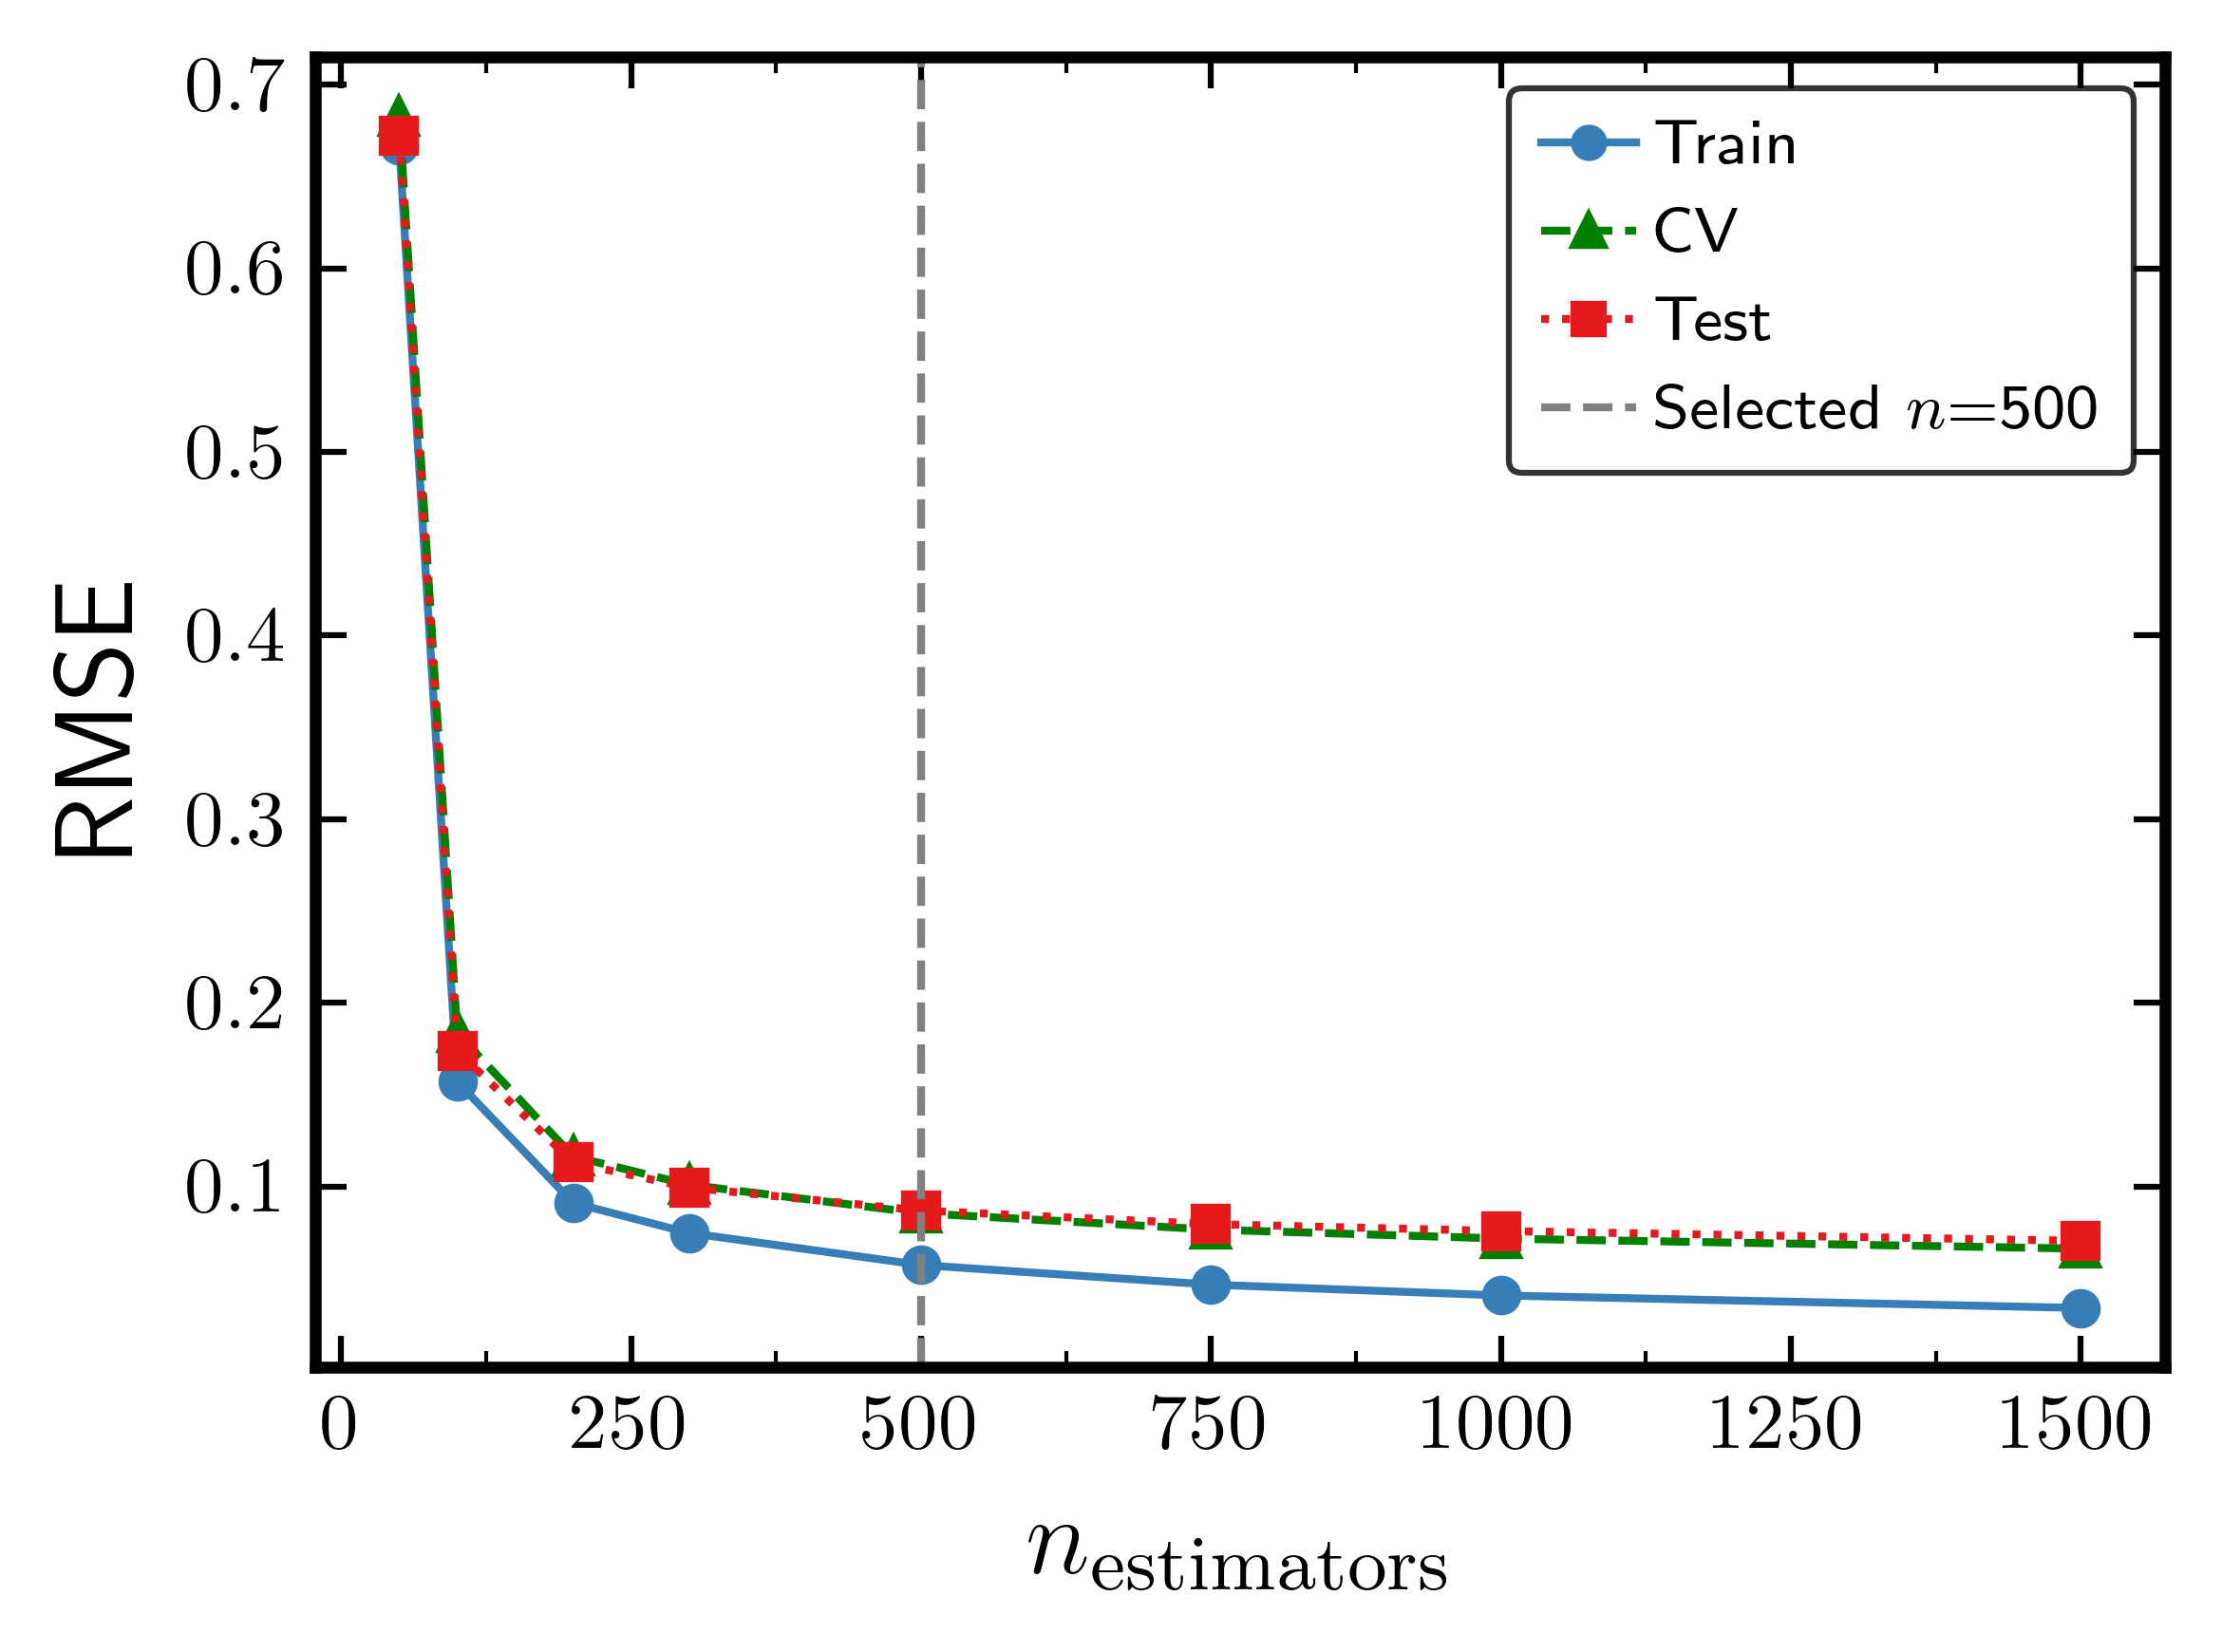

Saved: XGB_gamma_n_estimators_sweep


In [9]:
# Hyperparameter analysis: n_estimators sensitivity sweep (XGBoost)
# Hyperparameter comparison uses 5-fold CV RMSE; test RMSE is shown only as a holdout reference.
n_est_values = [50, 100, 200, 300, 500, 750, 1000, 1500]

train_rmse_n, cv_rmse_n, test_rmse_n = [], [], []
for _value in n_est_values:
    _xgb = XGBRegressor(
        n_estimators=_value,
        max_depth=xgb_model.max_depth,
        learning_rate=xgb_model.learning_rate,
        subsample=xgb_model.subsample,
        colsample_bytree=xgb_model.colsample_bytree,
        random_state=SEED,
        n_jobs=n_cpus,
    )
    _xgb.fit(X_train, y_train, verbose=False)
    train_rmse_n.append(np.sqrt(mean_squared_error(y_train, _xgb.predict(X_train))))
    test_rmse_n.append(np.sqrt(mean_squared_error(y_test,  _xgb.predict(X_test))))
    _cv = cross_validate(
        _xgb, X_train, y_train, cv=5,
        scoring={"rmse": "neg_root_mean_squared_error"},
        n_jobs=1,
    )
    cv_rmse_n.append(float(-_cv["test_rmse"].mean()))

print("n_estimators sweep complete.")
for _value, tr, cv, te in zip(n_est_values, train_rmse_n, cv_rmse_n, test_rmse_n):
    print(f"  n_est={_value:>5} | Train RMSE={tr:.4f}  CV RMSE={cv:.4f}  Test RMSE={te:.4f}")

fig, ax = ps.plot_init()
ax.plot(n_est_values, train_rmse_n, marker="o", markersize=ps.markersize,
        lw=ps.linewidth, color=ps.colors[2], label="Train")
ax.plot(n_est_values, cv_rmse_n, marker="^", markersize=ps.markersize,
        lw=ps.linewidth, color=ps.colors[1], label="CV")
ax.plot(n_est_values, test_rmse_n, marker="s", markersize=ps.markersize,
        lw=ps.linewidth, color=ps.colors[0], label="Test")
ax.axvline(xgb_model.n_estimators, ls="--", color="gray",
           lw=ps.linewidth, label=f"Selected $n$={xgb_model.n_estimators}")
ax.set_xlabel(r"$n_{\mathrm{estimators}}$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ps.style_legend(ax, loc="upper right")
plt.tight_layout()
ps.save_plot(fig, f"XGB_{target}_n_estimators_sweep", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: XGB_{target}_n_estimators_sweep")


max_depth sweep complete.
  depth=2 | Train RMSE=0.2426  CV RMSE=0.2501  Test RMSE=0.2575
  depth=3 | Train RMSE=0.1498  CV RMSE=0.1597  Test RMSE=0.1662
  depth=4 | Train RMSE=0.1029  CV RMSE=0.1174  Test RMSE=0.1191
  depth=5 | Train RMSE=0.0746  CV RMSE=0.0950  Test RMSE=0.0961
  depth=6 | Train RMSE=0.0572  CV RMSE=0.0854  Test RMSE=0.0868
  depth=7 | Train RMSE=0.0466  CV RMSE=0.0859  Test RMSE=0.0857
  depth=8 | Train RMSE=0.0382  CV RMSE=0.0962  Test RMSE=0.0893
  depth=10 | Train RMSE=0.0276  CV RMSE=0.1327  Test RMSE=0.1183


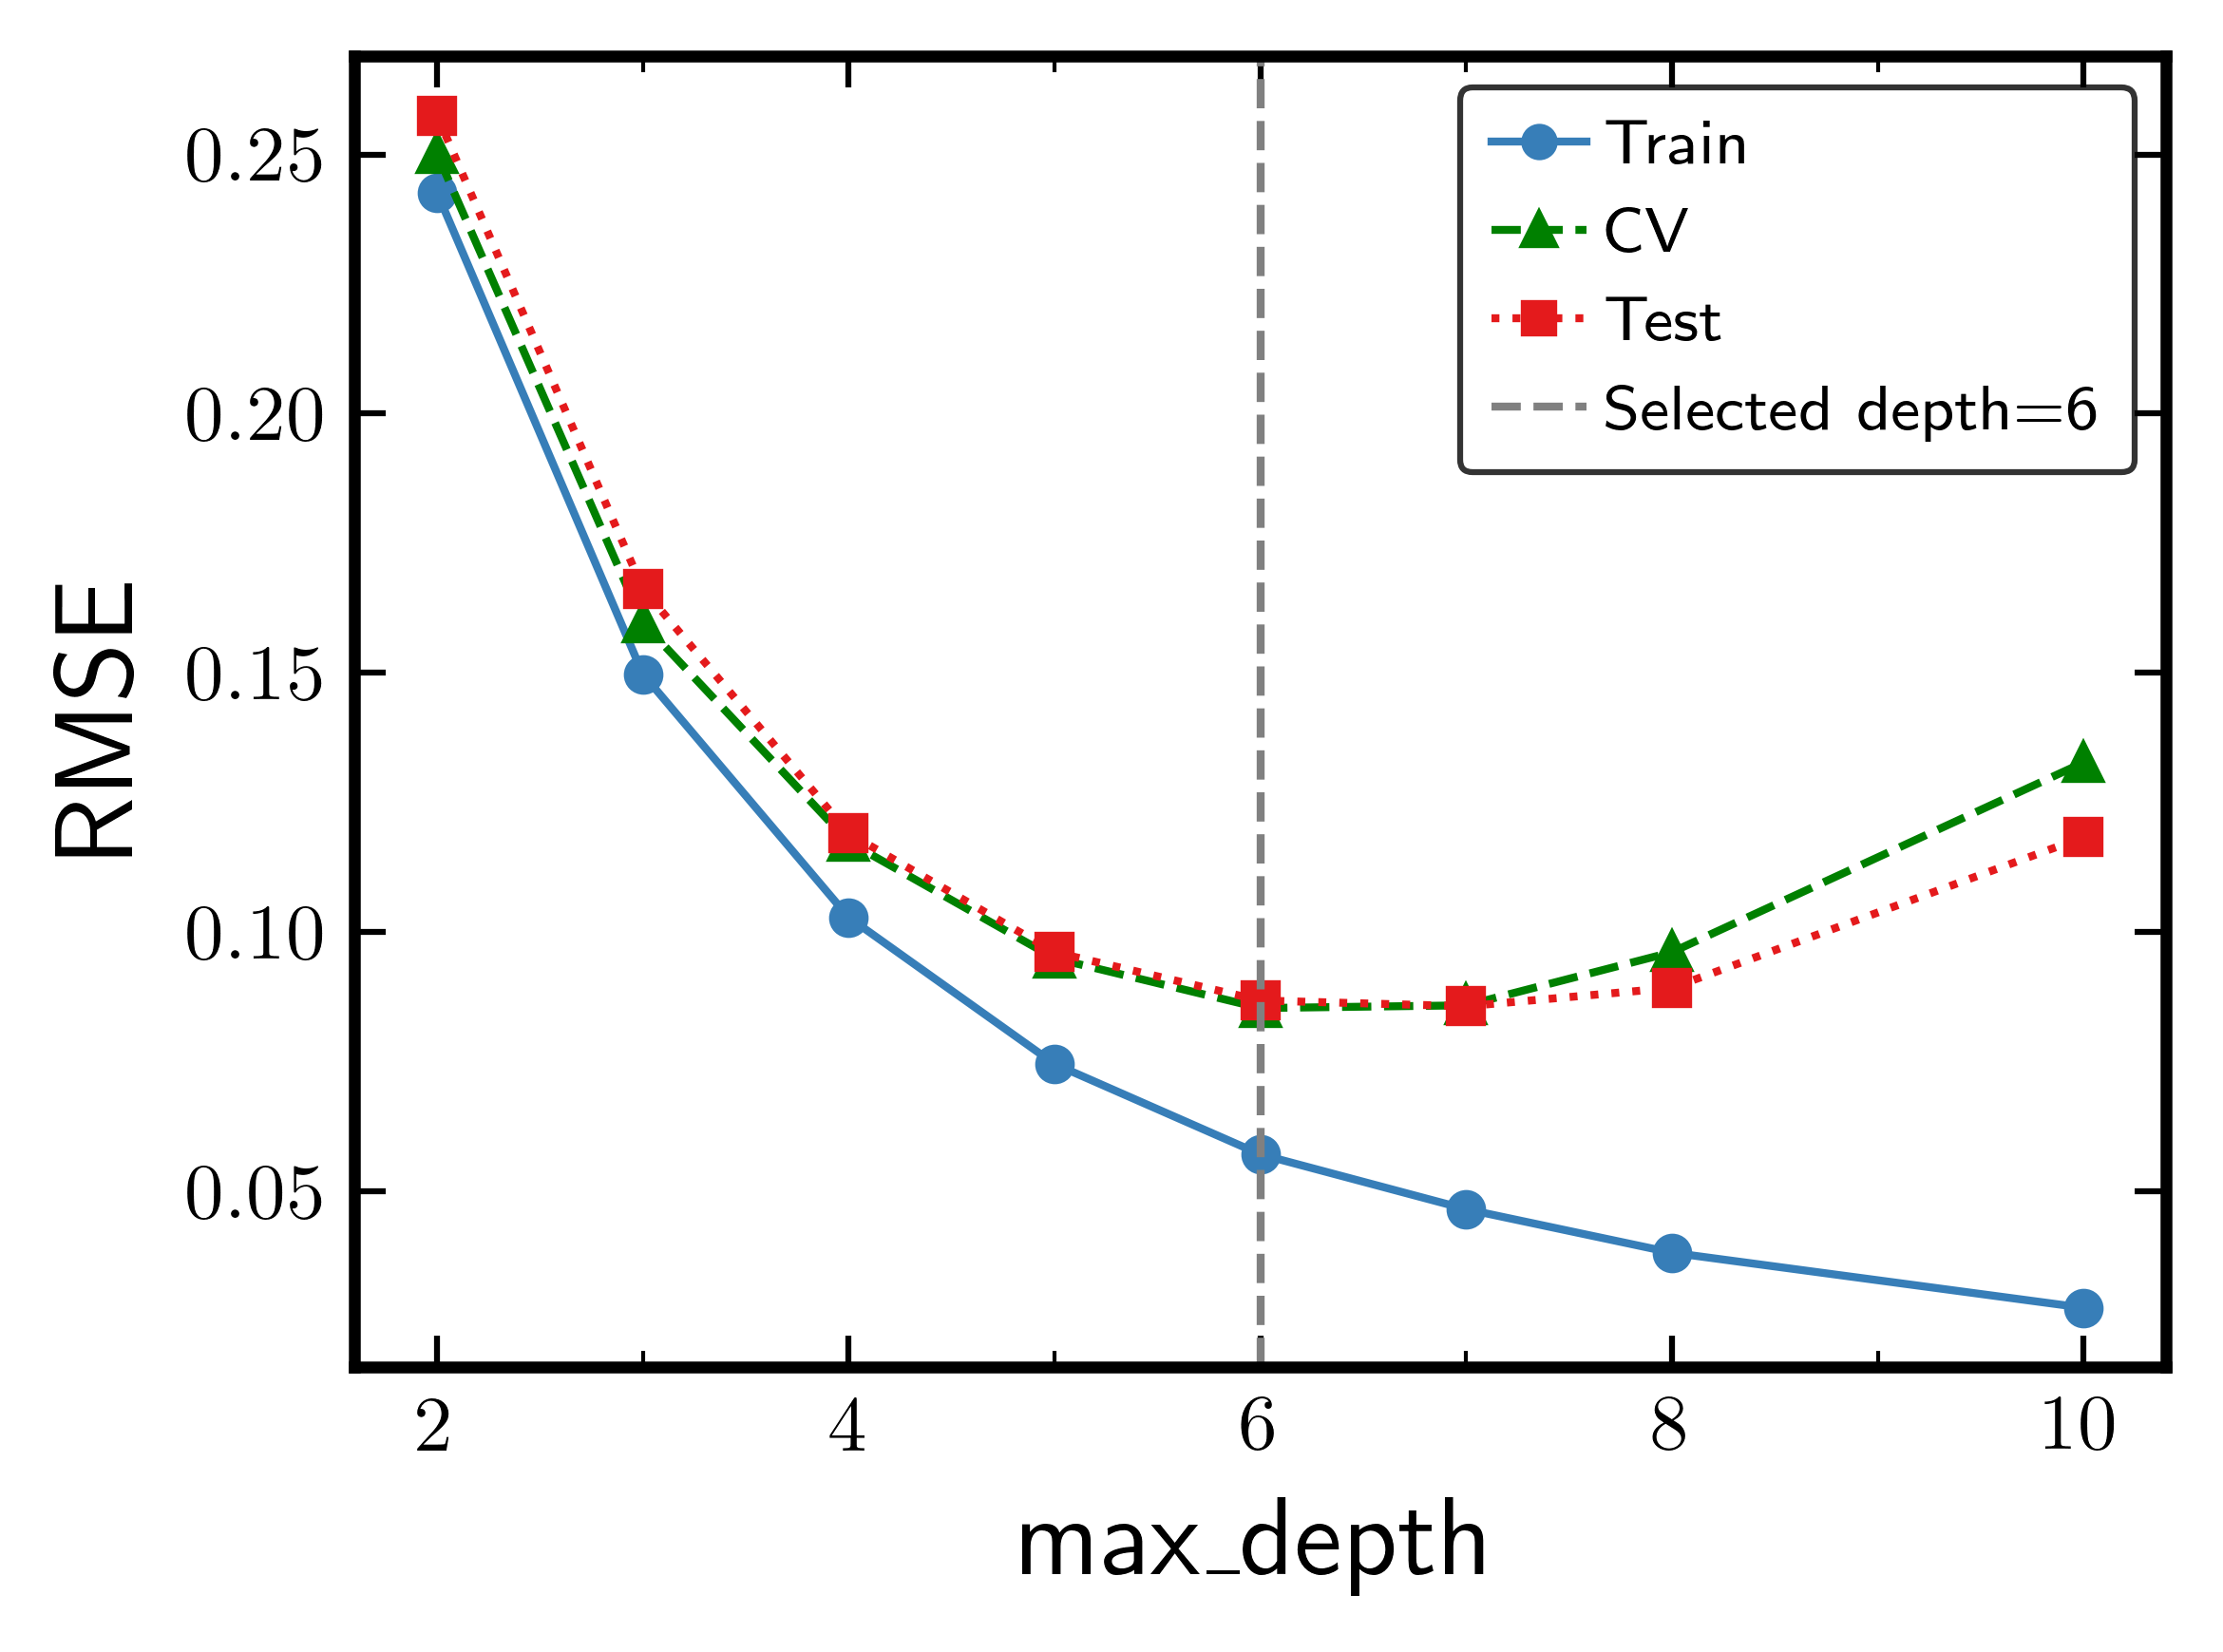

Saved: XGB_gamma_max_depth_sweep


In [10]:
# Hyperparameter analysis: max_depth sensitivity sweep (XGBoost)
# Hyperparameter comparison uses 5-fold CV RMSE; test RMSE is shown only as a holdout reference.
depth_values = [2, 3, 4, 5, 6, 7, 8, 10]

train_rmse_d, cv_rmse_d, test_rmse_d = [], [], []
for _value in depth_values:
    _xgb = XGBRegressor(
        n_estimators=xgb_model.n_estimators,
        max_depth=_value,
        learning_rate=xgb_model.learning_rate,
        subsample=xgb_model.subsample,
        colsample_bytree=xgb_model.colsample_bytree,
        random_state=SEED,
        n_jobs=n_cpus,
    )
    _xgb.fit(X_train, y_train, verbose=False)
    train_rmse_d.append(np.sqrt(mean_squared_error(y_train, _xgb.predict(X_train))))
    test_rmse_d.append(np.sqrt(mean_squared_error(y_test,  _xgb.predict(X_test))))
    _cv = cross_validate(
        _xgb, X_train, y_train, cv=5,
        scoring={"rmse": "neg_root_mean_squared_error"},
        n_jobs=1,
    )
    cv_rmse_d.append(float(-_cv["test_rmse"].mean()))

print("max_depth sweep complete.")
for _value, tr, cv, te in zip(depth_values, train_rmse_d, cv_rmse_d, test_rmse_d):
    print(f"  depth={_value} | Train RMSE={tr:.4f}  CV RMSE={cv:.4f}  Test RMSE={te:.4f}")

fig, ax = ps.plot_init()
ax.plot(depth_values, train_rmse_d, marker="o", markersize=ps.markersize,
        lw=ps.linewidth, color=ps.colors[2], label="Train")
ax.plot(depth_values, cv_rmse_d, marker="^", markersize=ps.markersize,
        lw=ps.linewidth, color=ps.colors[1], label="CV")
ax.plot(depth_values, test_rmse_d, marker="s", markersize=ps.markersize,
        lw=ps.linewidth, color=ps.colors[0], label="Test")
ax.axvline(xgb_model.max_depth, ls="--", color="gray",
           lw=ps.linewidth, label=f"Selected depth={xgb_model.max_depth}")
ax.set_xlabel(r"max\_depth", fontsize=ps.label_fontsize)
ax.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ps.style_legend(ax, loc="upper right")
plt.tight_layout()
ps.save_plot(fig, f"XGB_{target}_max_depth_sweep", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: XGB_{target}_max_depth_sweep")


learning_rate sweep complete.
  lr=0.001 | Train RMSE=3.9034  CV RMSE=3.9086  Test RMSE=3.9066
  lr=0.005 | Train RMSE=0.6857  CV RMSE=0.7020  Test RMSE=0.6917
  lr=0.010 | Train RMSE=0.1623  CV RMSE=0.1900  Test RMSE=0.1806
  lr=0.050 | Train RMSE=0.0572  CV RMSE=0.0854  Test RMSE=0.0868
  lr=0.100 | Train RMSE=0.0422  CV RMSE=0.0735  Test RMSE=0.0777
  lr=0.200 | Train RMSE=0.0351  CV RMSE=0.0739  Test RMSE=0.0766
  lr=0.300 | Train RMSE=0.0332  CV RMSE=0.0813  Test RMSE=0.0817
  lr=0.500 | Train RMSE=0.0325  CV RMSE=0.0998  Test RMSE=0.0946


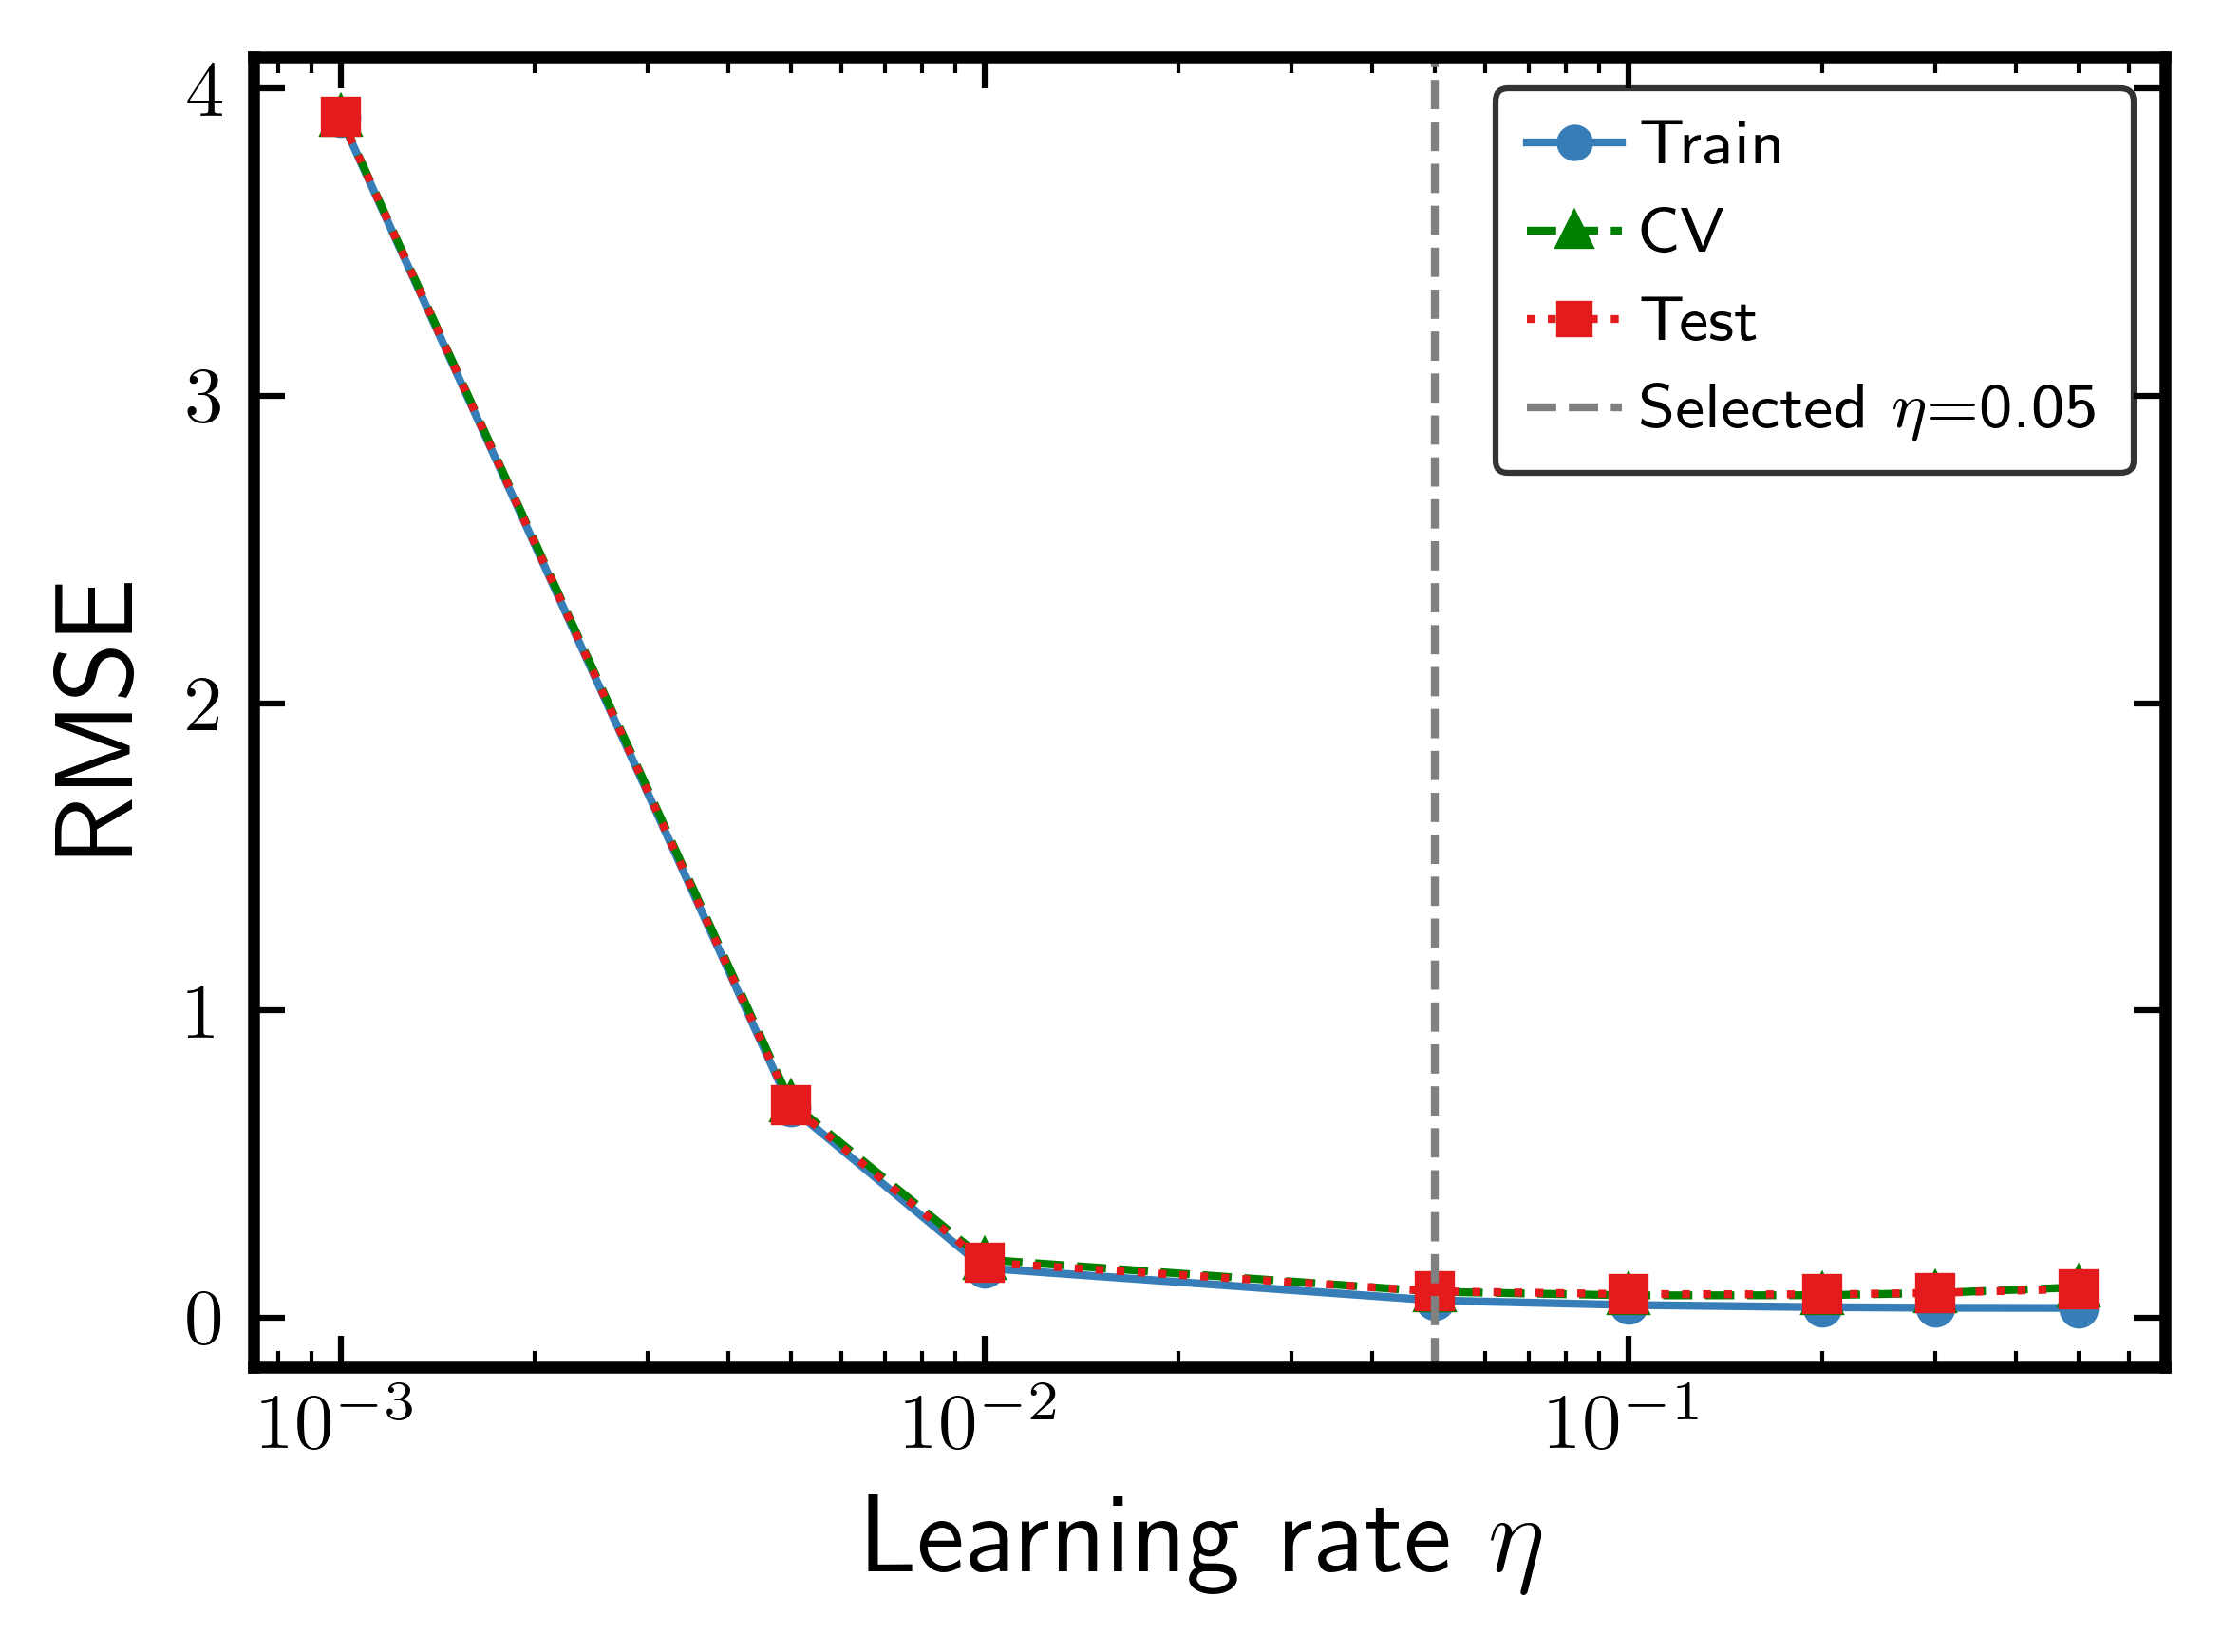

Saved: XGB_gamma_learning_rate_sweep


In [11]:
# Hyperparameter analysis: learning_rate sensitivity sweep (XGBoost)
# Hyperparameter comparison uses 5-fold CV RMSE; test RMSE is shown only as a holdout reference.
lr_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

train_rmse_lr, cv_rmse_lr, test_rmse_lr = [], [], []
for _value in lr_values:
    _xgb = XGBRegressor(
        n_estimators=xgb_model.n_estimators,
        max_depth=xgb_model.max_depth,
        learning_rate=_value,
        subsample=xgb_model.subsample,
        colsample_bytree=xgb_model.colsample_bytree,
        random_state=SEED,
        n_jobs=n_cpus,
    )
    _xgb.fit(X_train, y_train, verbose=False)
    train_rmse_lr.append(np.sqrt(mean_squared_error(y_train, _xgb.predict(X_train))))
    test_rmse_lr.append(np.sqrt(mean_squared_error(y_test,  _xgb.predict(X_test))))
    _cv = cross_validate(
        _xgb, X_train, y_train, cv=5,
        scoring={"rmse": "neg_root_mean_squared_error"},
        n_jobs=1,
    )
    cv_rmse_lr.append(float(-_cv["test_rmse"].mean()))

print("learning_rate sweep complete.")
for _value, tr, cv, te in zip(lr_values, train_rmse_lr, cv_rmse_lr, test_rmse_lr):
    print(f"  lr={_value:.3f} | Train RMSE={tr:.4f}  CV RMSE={cv:.4f}  Test RMSE={te:.4f}")

fig, ax = ps.plot_init()
ax.semilogx(lr_values, train_rmse_lr, marker="o", markersize=ps.markersize,
        lw=ps.linewidth, color=ps.colors[2], label="Train")
ax.semilogx(lr_values, cv_rmse_lr, marker="^", markersize=ps.markersize,
        lw=ps.linewidth, color=ps.colors[1], label="CV")
ax.semilogx(lr_values, test_rmse_lr, marker="s", markersize=ps.markersize,
        lw=ps.linewidth, color=ps.colors[0], label="Test")
ax.axvline(xgb_model.learning_rate, ls="--", color="gray",
           lw=ps.linewidth, label=rf"Selected $\eta$={xgb_model.learning_rate}")
ax.set_xlabel(r"Learning rate $\eta$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"RMSE", fontsize=ps.label_fontsize)
ax.xaxis.set_minor_locator(LogLocator(subs="auto"))
ps.style_legend(ax, loc="upper right")
plt.tight_layout()
ps.save_plot(fig, f"XGB_{target}_learning_rate_sweep", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: XGB_{target}_learning_rate_sweep")


Outlier threshold (3σ): ±0.197480
Test outliers: 81/2904 (2.79%)
Val  outliers: 83/2905  (2.86%)
Saved: XGB_gamma_outliers.csv (164 rows)
  idx split  source_id  temperature   pressure    actual  predicted  residual
15340  test         79        215.0 110.061942 14.422657  15.023201 -0.600544
 3869  test         20        200.0   7.822050 19.742620  19.947834 -0.205214
15505  test         80        200.0  98.720251 16.976981  17.300421 -0.323439
 4068  test         21        205.0 145.203886 16.262405  17.494900 -1.232494
16244  test         83        280.0  47.069480  3.012914   3.213978 -0.201064
15314  test         79        200.0 137.135734 17.080173  17.828335 -0.748162
11118  test         57        240.0  23.330406 10.605697  10.400860  0.204837
 5362  test         27        265.0  39.921721  5.518676   5.298069  0.220607
 5251  test         27        210.0  19.182969 17.977992  17.726021  0.251971
  666  test          3        240.0  25.631158 10.628479  10.861045 -0.232565
1533

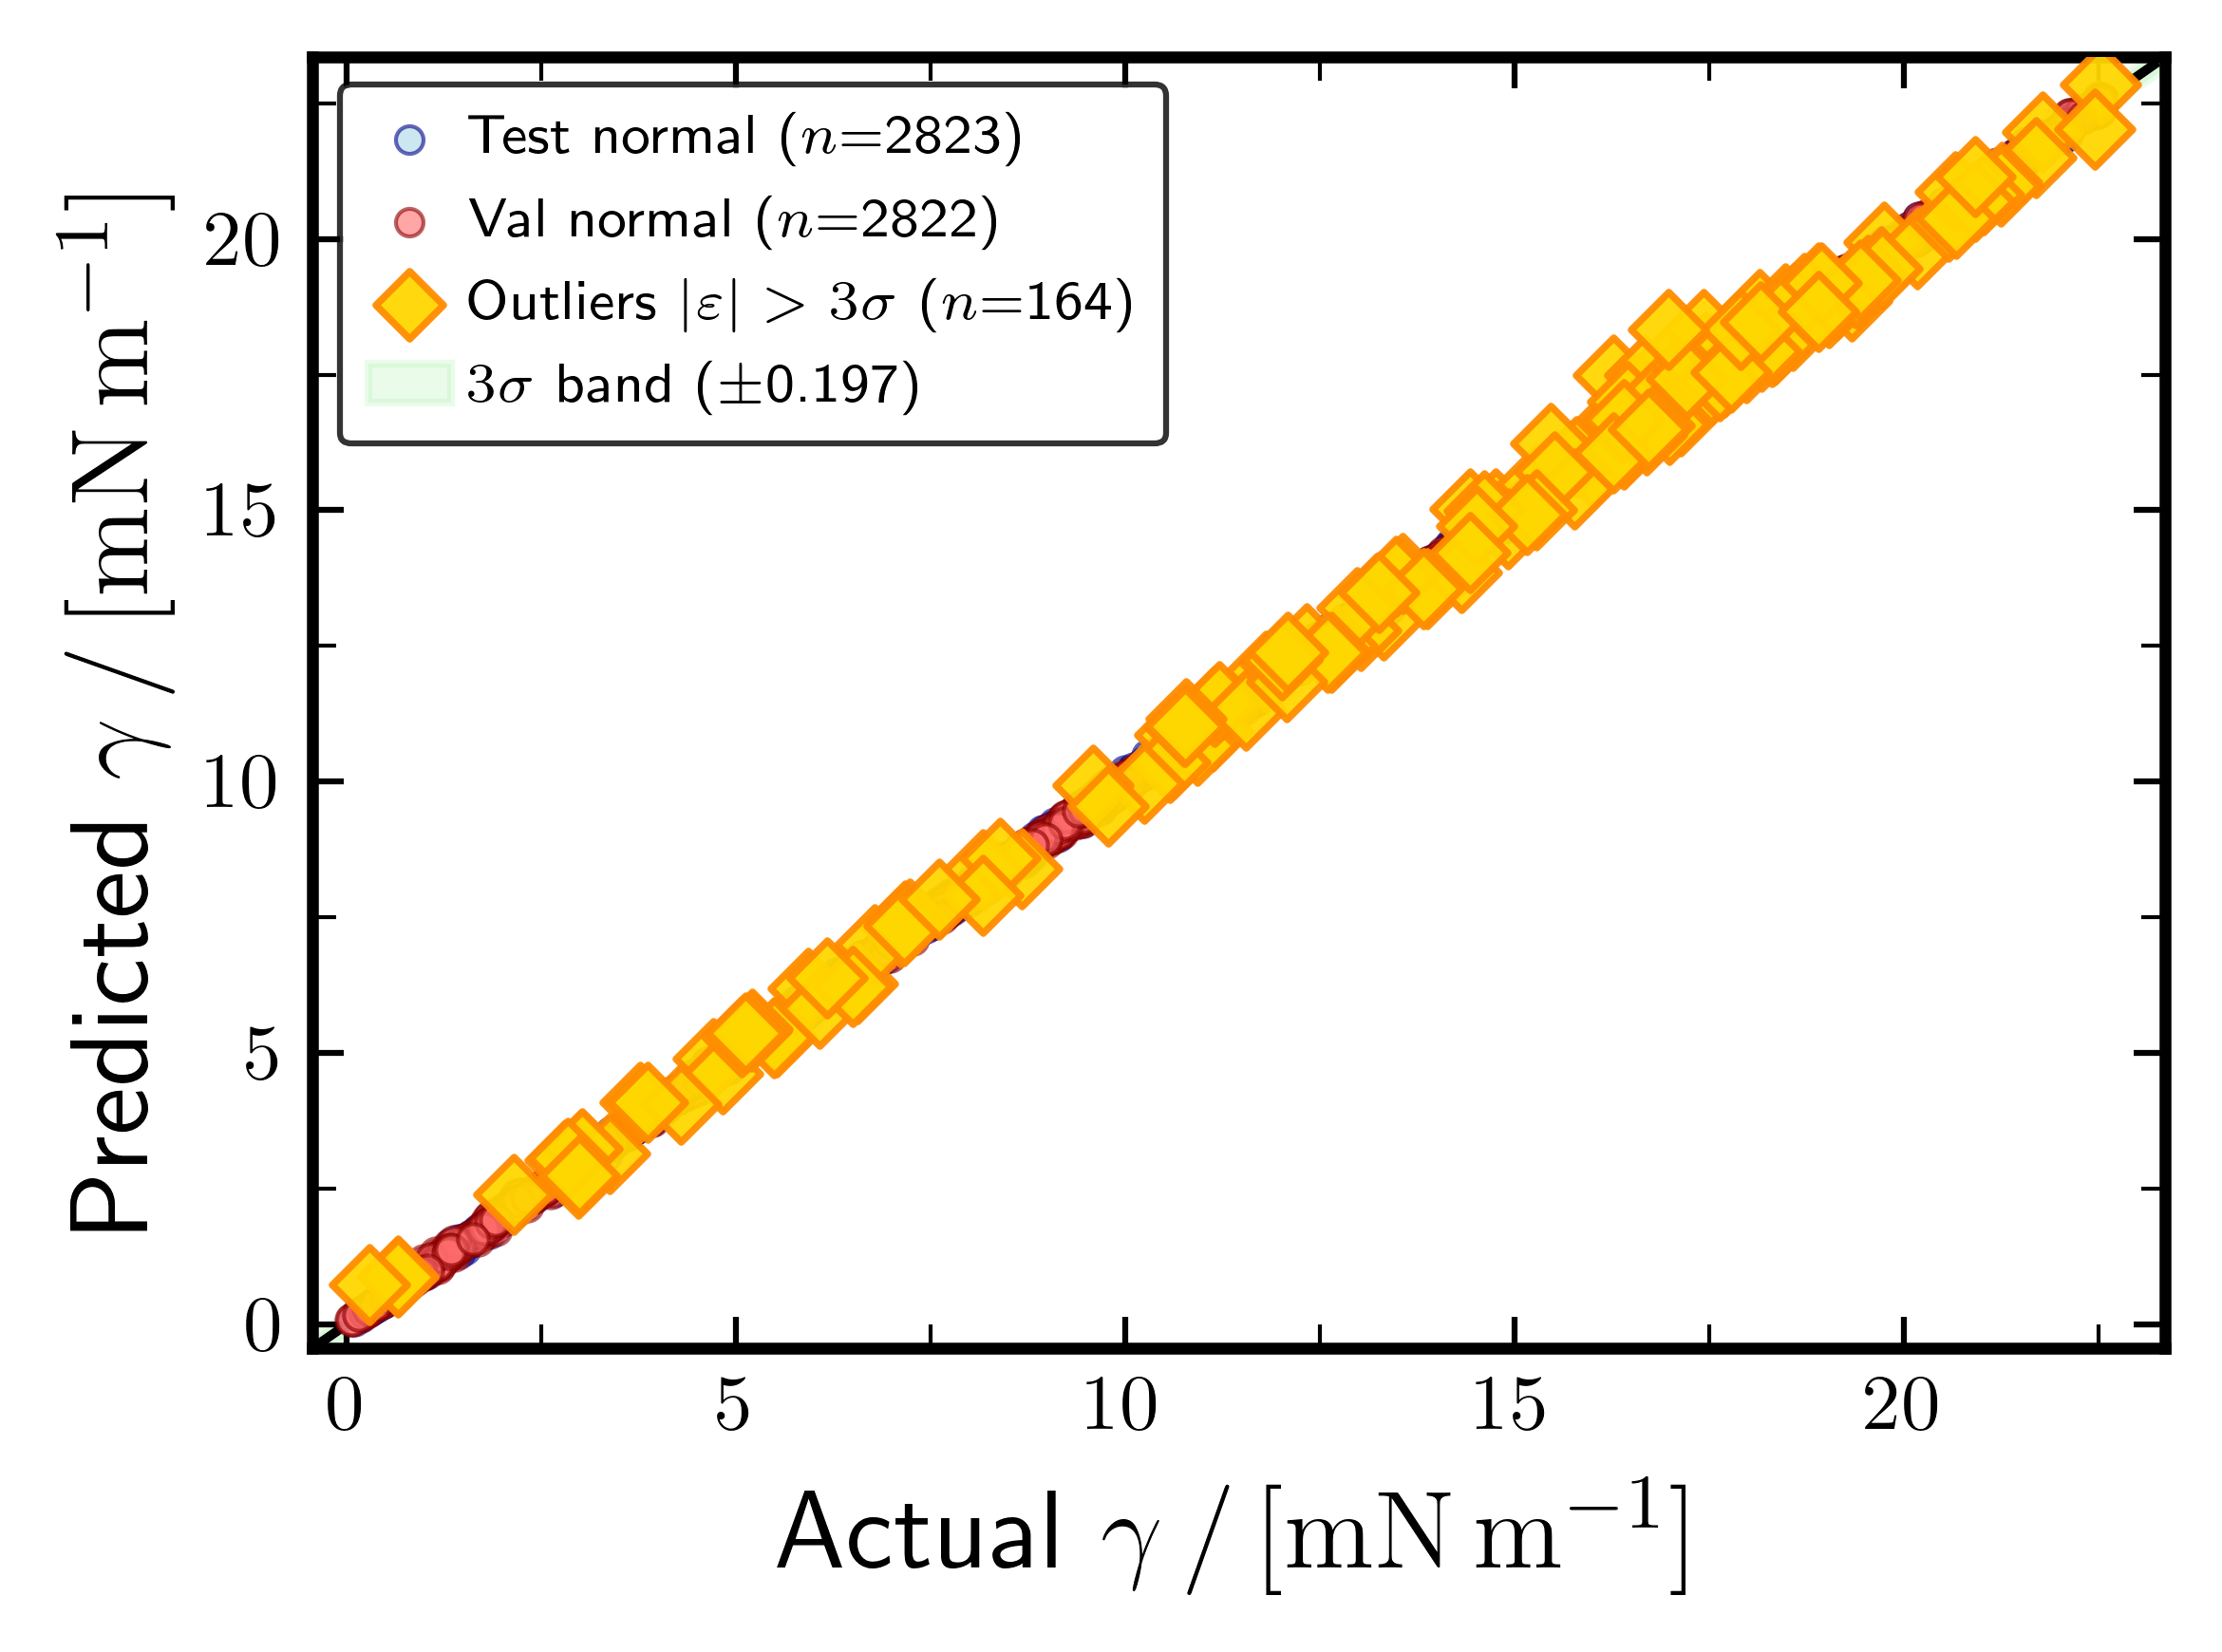

Saved: XGB_gamma_outlier_parity


In [12]:
# Outlier flagging: test + val samples where |residual| > 3 * global std
all_resids_global = np.concatenate([
    np.asarray(y_train) - y_train_pred,
    np.asarray(y_test)  - y_test_pred,
    np.asarray(y_val)   - y_val_pred,
])
threshold = 3.0 * all_resids_global.std()

test_resids   = np.asarray(y_test) - y_test_pred
val_resids    = np.asarray(y_val)  - y_val_pred
test_out_mask = np.abs(test_resids) > threshold
val_out_mask  = np.abs(val_resids)  > threshold

n_test_out = int(test_out_mask.sum())
n_val_out  = int(val_out_mask.sum())
print(f"Outlier threshold (3σ): ±{threshold:.6f}")
print(f"Test outliers: {n_test_out}/{len(y_test)} ({100*n_test_out/len(y_test):.2f}%)")
print(f"Val  outliers: {n_val_out}/{len(y_val)}  ({100*n_val_out/len(y_val):.2f}%)")

outlier_df = pd.concat([
    pd.DataFrame({
        "idx":         y_test.index[test_out_mask],
        "split":       "test",
        "source_id":   df.loc[y_test.index[test_out_mask], "source_id"].values,
        "temperature": df.loc[y_test.index[test_out_mask], "temperature"].values,
        "pressure":    df.loc[y_test.index[test_out_mask], "pressure"].values,
        "actual":      np.asarray(y_test)[test_out_mask],
        "predicted":   y_test_pred[test_out_mask],
        "residual":    test_resids[test_out_mask],
    }),
    pd.DataFrame({
        "idx":         y_val.index[val_out_mask],
        "split":       "val",
        "source_id":   df.loc[y_val.index[val_out_mask], "source_id"].values,
        "temperature": df.loc[y_val.index[val_out_mask], "temperature"].values,
        "pressure":    df.loc[y_val.index[val_out_mask], "pressure"].values,
        "actual":      np.asarray(y_val)[val_out_mask],
        "predicted":   y_val_pred[val_out_mask],
        "residual":    val_resids[val_out_mask],
    }),
], ignore_index=True)
outlier_df.to_csv(os.path.join(OUTPUT_FOLDER, f"XGB_{target}_outliers.csv"), index=False)
print(f"Saved: XGB_{target}_outliers.csv ({len(outlier_df)} rows)")
print(outlier_df.to_string(index=False))

# Parity plot highlighting outliers
fig, ax = ps.plot_init()

for y_true_sp, y_pred_sp, out_mask, fc, ec, lbl in [
    (y_test, y_test_pred, test_out_mask, "lightblue", "darkblue", "Test"),
    (y_val,  y_val_pred,  val_out_mask,  "#FF6B6B",   "darkred",  "Val"),
]:
    norm = ~out_mask
    ax.scatter(
        np.asarray(y_true_sp)[norm], y_pred_sp[norm],
        alpha=0.6, s=15, facecolors=fc, edgecolors=ec,
        linewidths=0.5, zorder=2,
        label=rf"{lbl} normal ($n$={int(norm.sum())})",
    )

all_out_true = np.concatenate([np.asarray(y_test)[test_out_mask], np.asarray(y_val)[val_out_mask]])
all_out_pred = np.concatenate([y_test_pred[test_out_mask], y_val_pred[val_out_mask]])
if len(all_out_true) > 0:
    ax.scatter(
        all_out_true, all_out_pred,
        alpha=0.95, s=45, facecolors="gold", edgecolors="darkorange",
        linewidths=0.9, marker="D", zorder=4,
        label=rf"Outliers $|\varepsilon|>3\sigma$ ($n$={len(all_out_true)})",
    )

all_vals = np.concatenate([np.asarray(y_test), np.asarray(y_val), y_test_pred, y_val_pred])
lims     = [all_vals.min() - 0.5, all_vals.max() + 0.5]
x_line   = np.array(lims)
ax.fill_between(x_line, x_line - threshold, x_line + threshold,
                color="lightgreen", alpha=0.18, zorder=0,
                label=rf"$3\sigma$ band ($\pm${threshold:.3f})")
ax.plot(lims, lims, "k--", lw=1.2, zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

target_label_str = ps.label_map.get(target.lower(), target)
ax.set_xlabel(f"Actual {target_label_str}", fontsize=ps.label_fontsize)
ax.set_ylabel(f"Predicted {target_label_str}", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper left', fontsize=ps.label_fontsize * 0.5)
plt.tight_layout()
ps.save_plot(fig, f"XGB_{target}_outlier_parity", folder=OUTPUT_FOLDER)
plt.show()
print(f"Saved: XGB_{target}_outlier_parity")

In [13]:
# XGBoost Feature Importance
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=list(df[features].columns)
).sort_values(ascending=False)

print("\nXGBoost Feature Importance (gain):")
print(xgb_importance.to_string())


XGBoost Feature Importance (gain):
temperature           0.852099
pressure              0.113017
z_hydrogen            0.021676
z_carbon dioxide      0.005647
z_nitrogen            0.002462
z_methane             0.001662
z_hydrogen sulfide    0.001568
z_argon               0.001000
z_carbon monoxide     0.000643
z_oxygen              0.000226


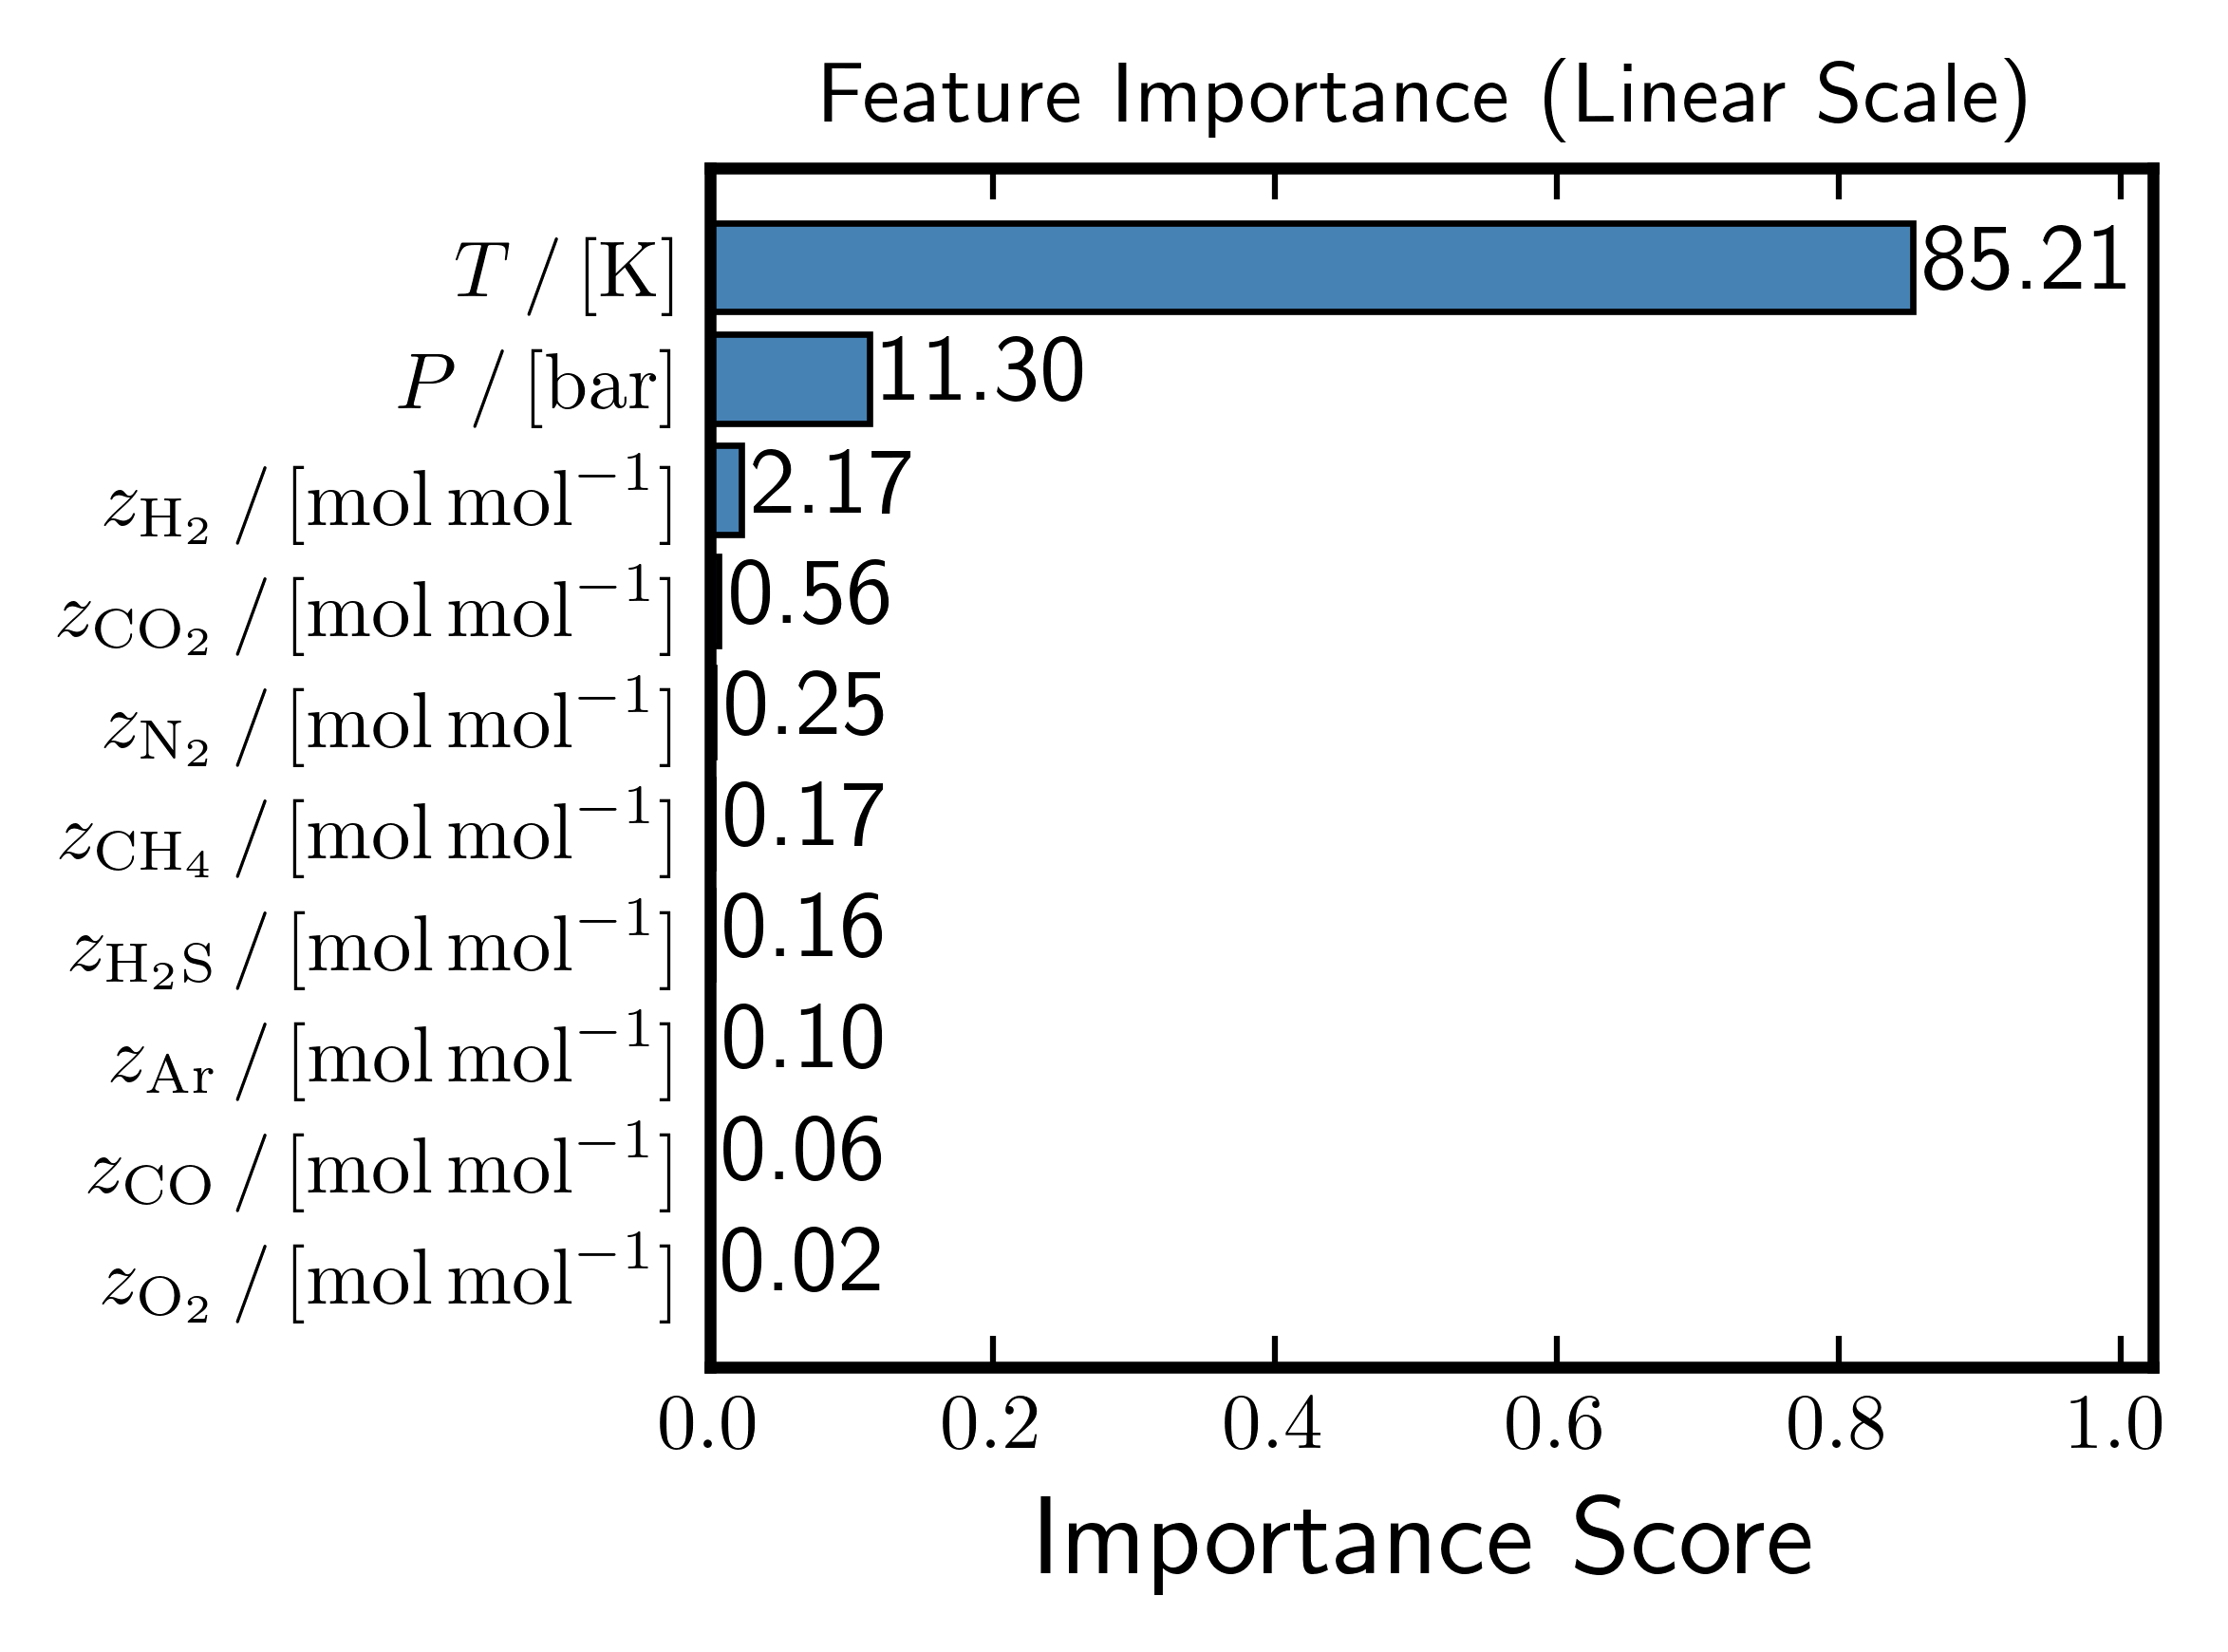

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Feature Importance (Linear Scale)'}, xlabel='Importance Score'>)

In [14]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="gamma",
    feature_importances=xgb_model.feature_importances_,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

# Plot feature importance (Linear Scale)
post.plot_feature_importance(scale="linear", color="steelblue", save_path="XGB_gamma_feature_importance_linear", folder=OUTPUT_FOLDER)

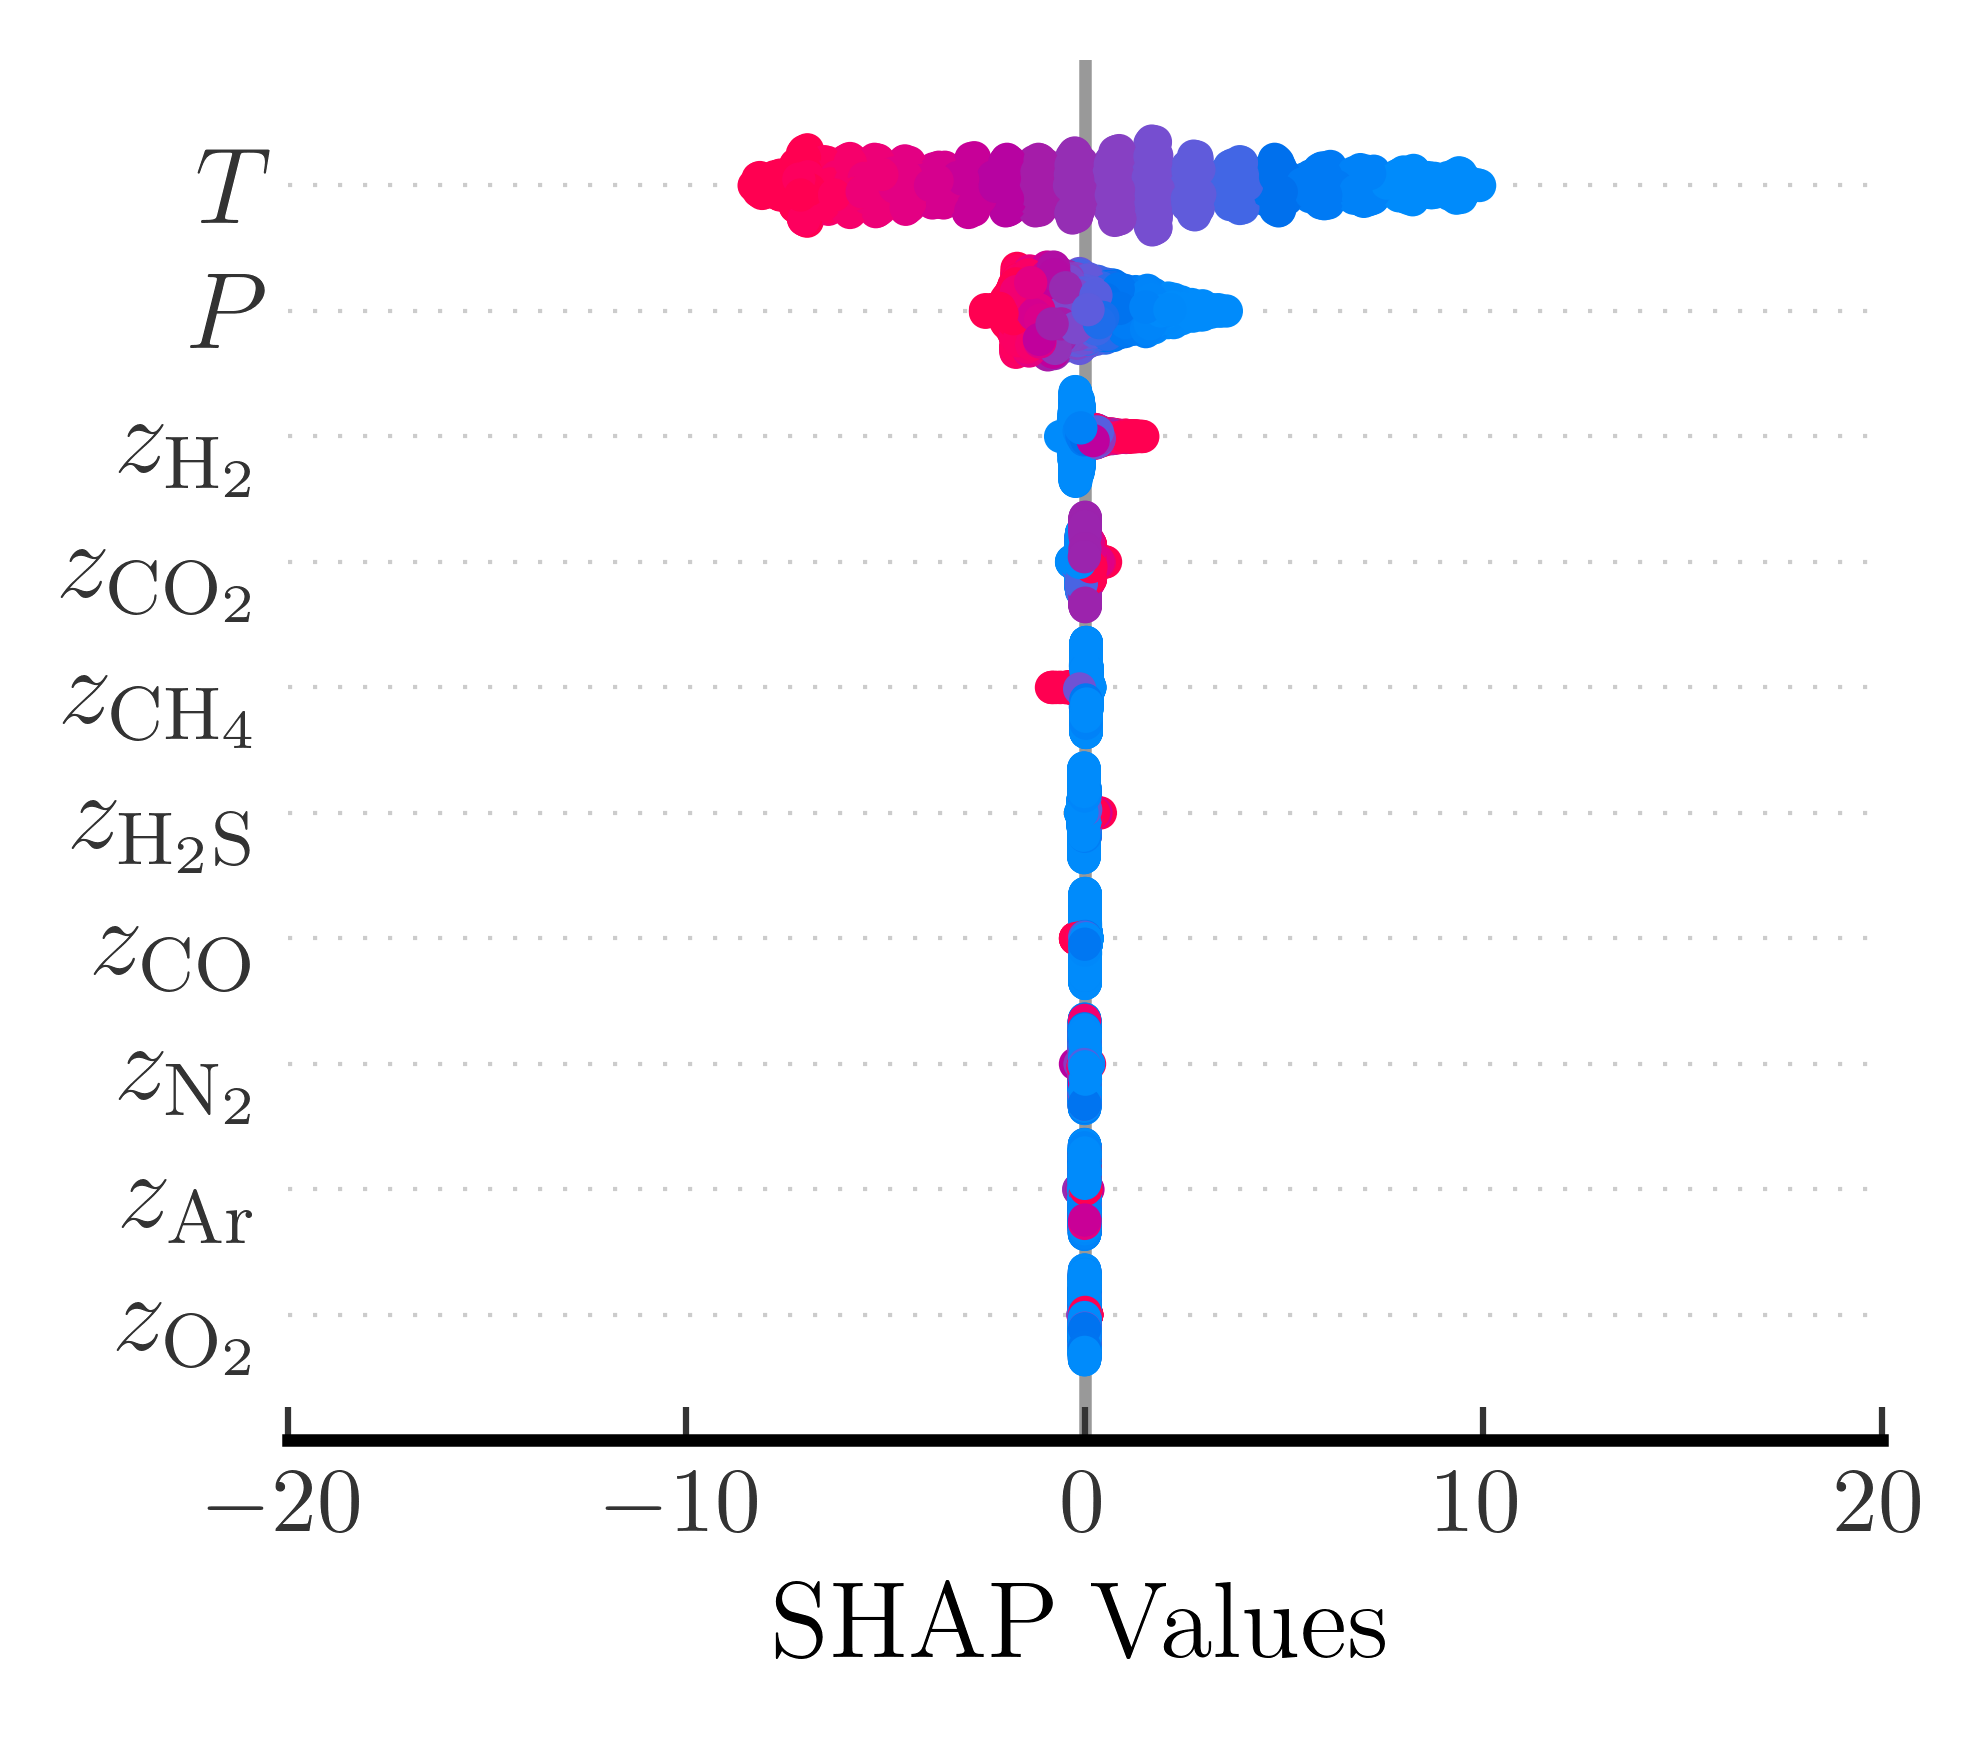

In [15]:
label_map = {
    "temperature": r"$T$",
    "pressure": r"$P$",
    "z_carbon dioxide": r"$z_{\mathrm{CO_2}}$",
    "z_hydrogen": r"$z_{\mathrm{H_2}}$",
    "z_argon": r"$z_{\mathrm{Ar}}$",
    "z_nitrogen": r"$z_{\mathrm{N_2}}$",
    "z_methane": r"$z_{\mathrm{CH_4}}$",
    "z_oxygen": r"$z_{\mathrm{O_2}}$",
    "z_carbon monoxide": r"$z_{\mathrm{CO}}$",
    "z_hydrogen sulfide": r"$z_{\mathrm{H_2S}}$",
    "gamma": r"$\gamma$",
}

from matplotlib.colors import Normalize

# SHAP Values — XGBoost
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

feature_labels = [label_map.get(f, f) for f in features]
shap_df = pd.DataFrame(shap_values, columns=feature_labels)

# Plot 1: Beeswarm Summary
fig, ax = ps.plot_init()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_labels,
    show=False,
    plot_size=None)
ax = plt.gca()
ax.set_xlabel(r"$\mathrm{SHAP\;Values}$")

plt.gcf().axes[-1].remove()
sm = plt.cm.ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=shap.plots.colors.red_blue)
sm.set_array([])
plt.xlim(-20,20)
plt.tight_layout()
ps.save_plot(fig, "XGB_gamma_shap_summary", folder=OUTPUT_FOLDER)
plt.show()

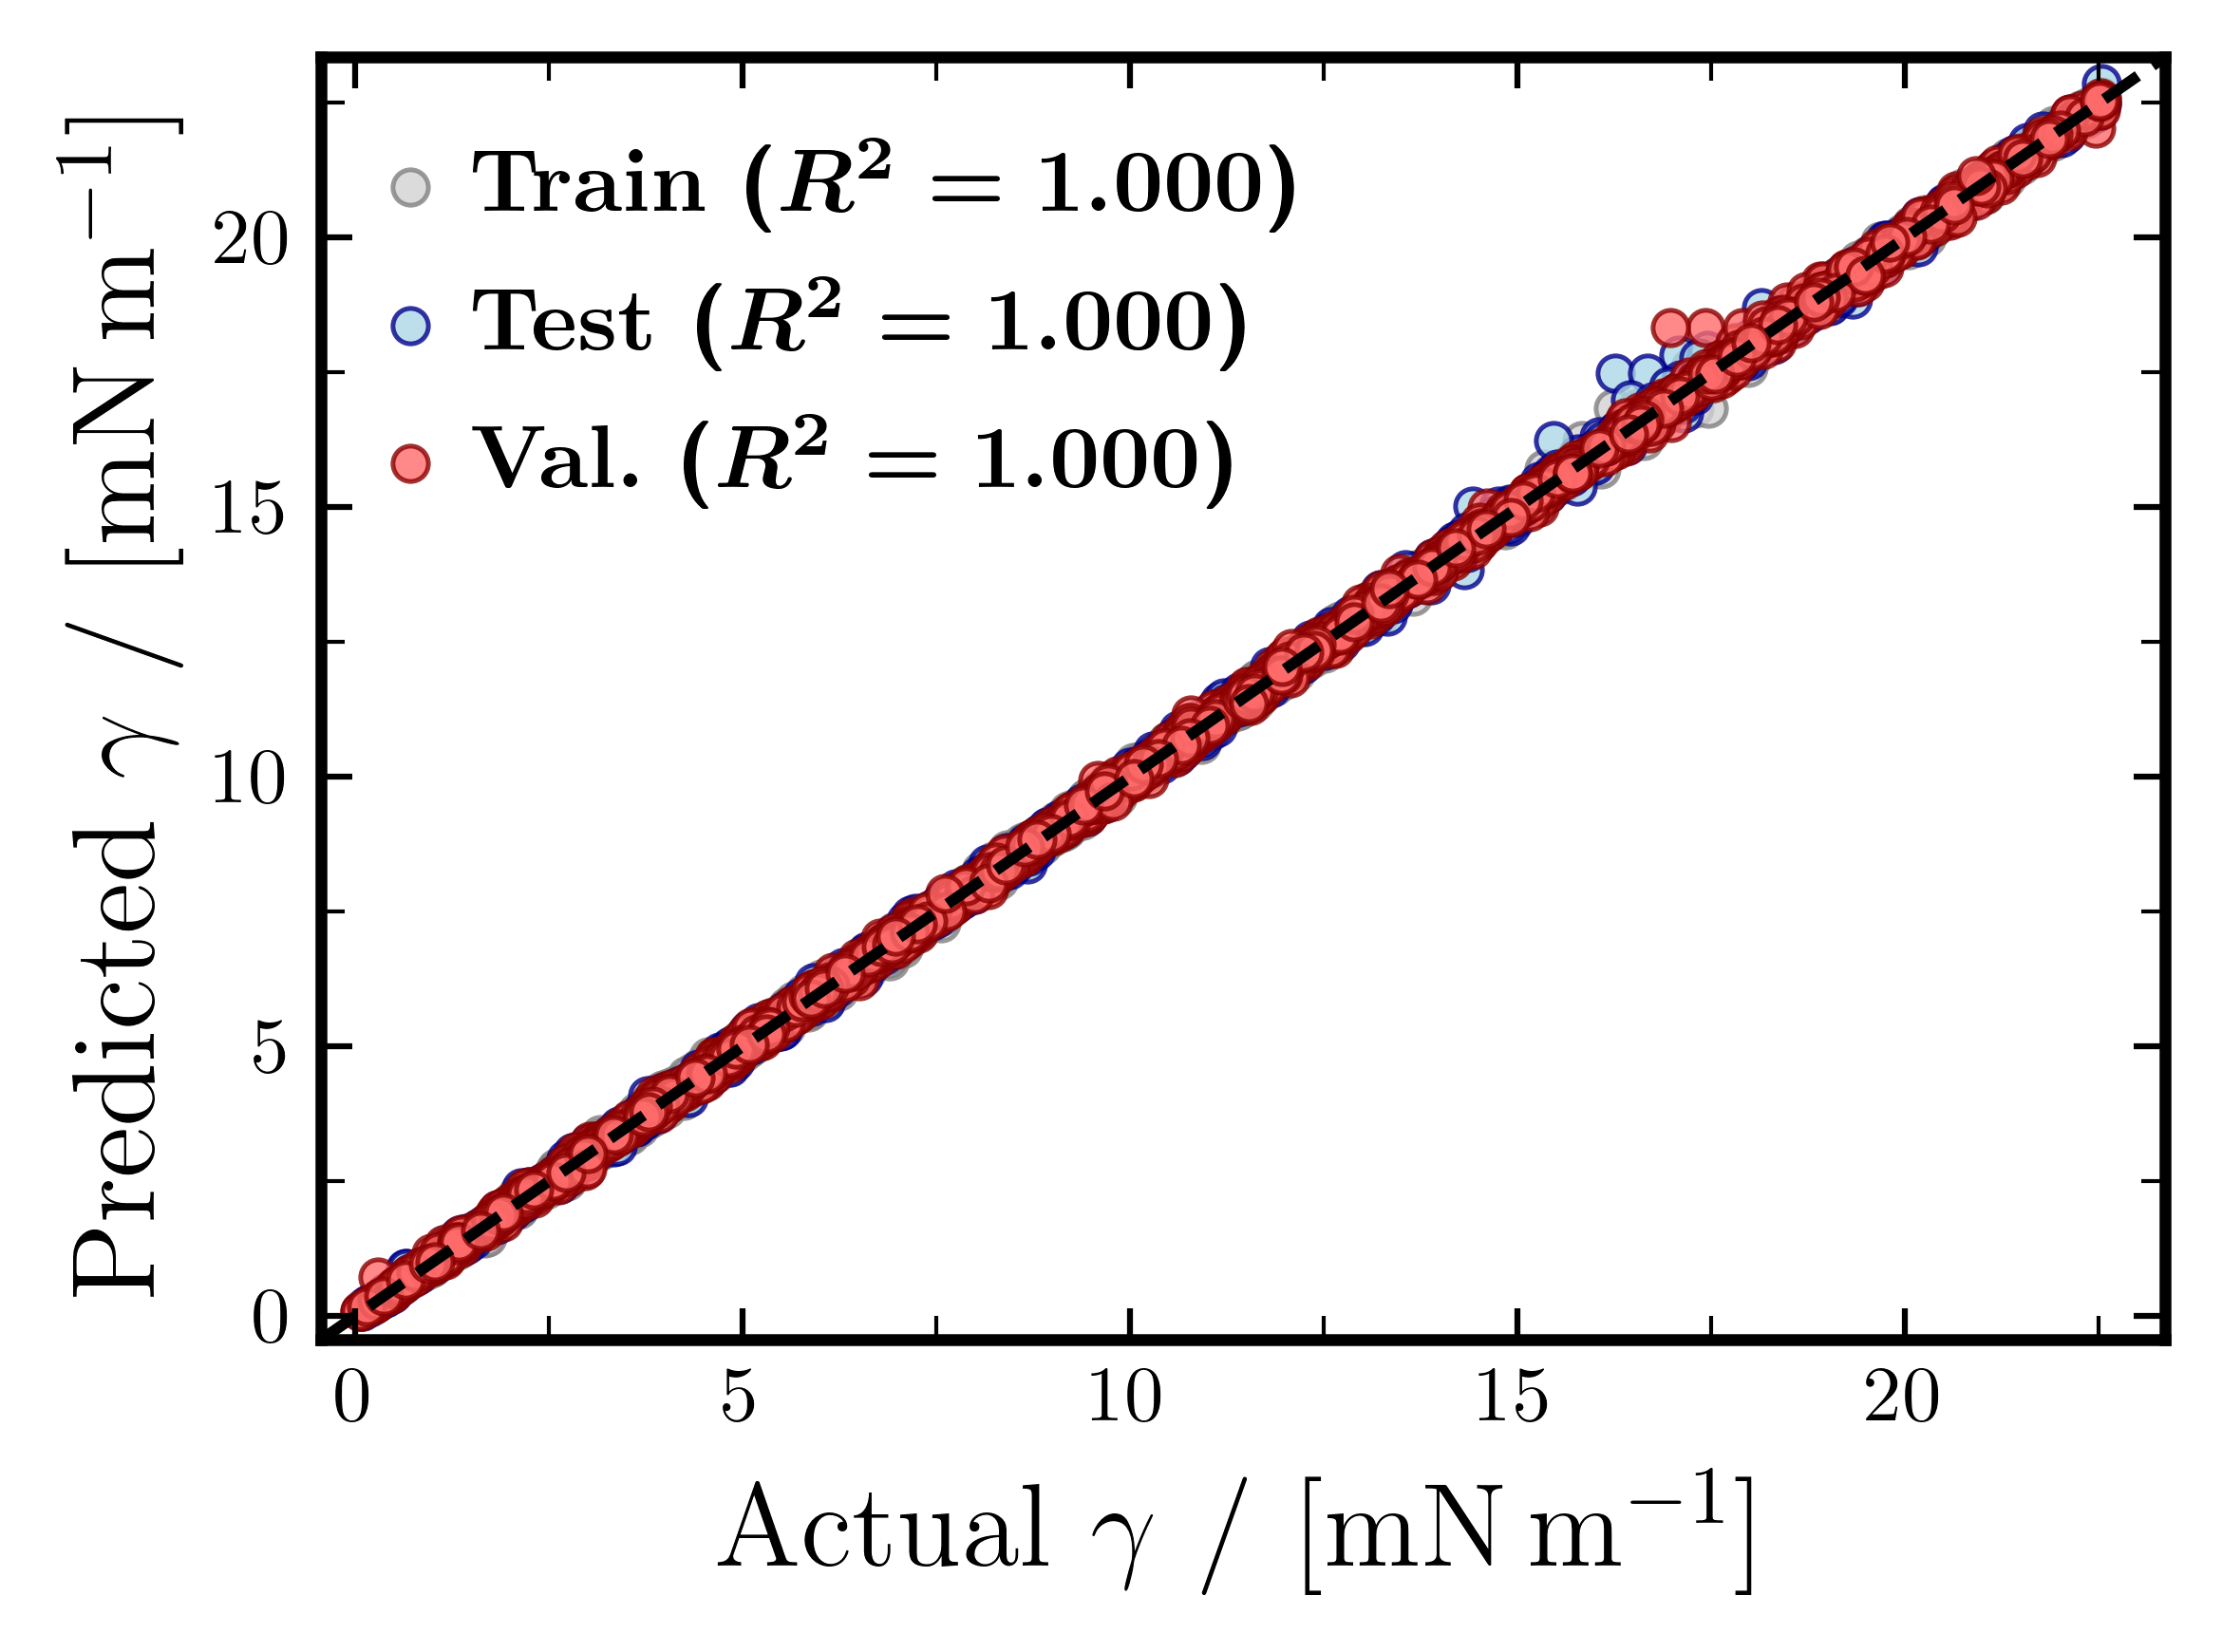

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Actual}$ $\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='$\\mathrm{Predicted}$ $\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>)

In [16]:
# Parity plot
post.plot_parity(model_name="XGBoost", save_path="XGB_gamma_parity_plot", folder=OUTPUT_FOLDER,
                 legend_loc=[0.005,0.62], # legend location
legend_handletextpad=0.2, # gap between marker and text
legend_handlelength=1.0, # marker-box width (smaller -> marker closer to text)
label_fontsize=15, # x/y axis label size
labelpad=4, # gap between axis and its label (points)
decimals=3, # decimal places for R^2 in legend
)

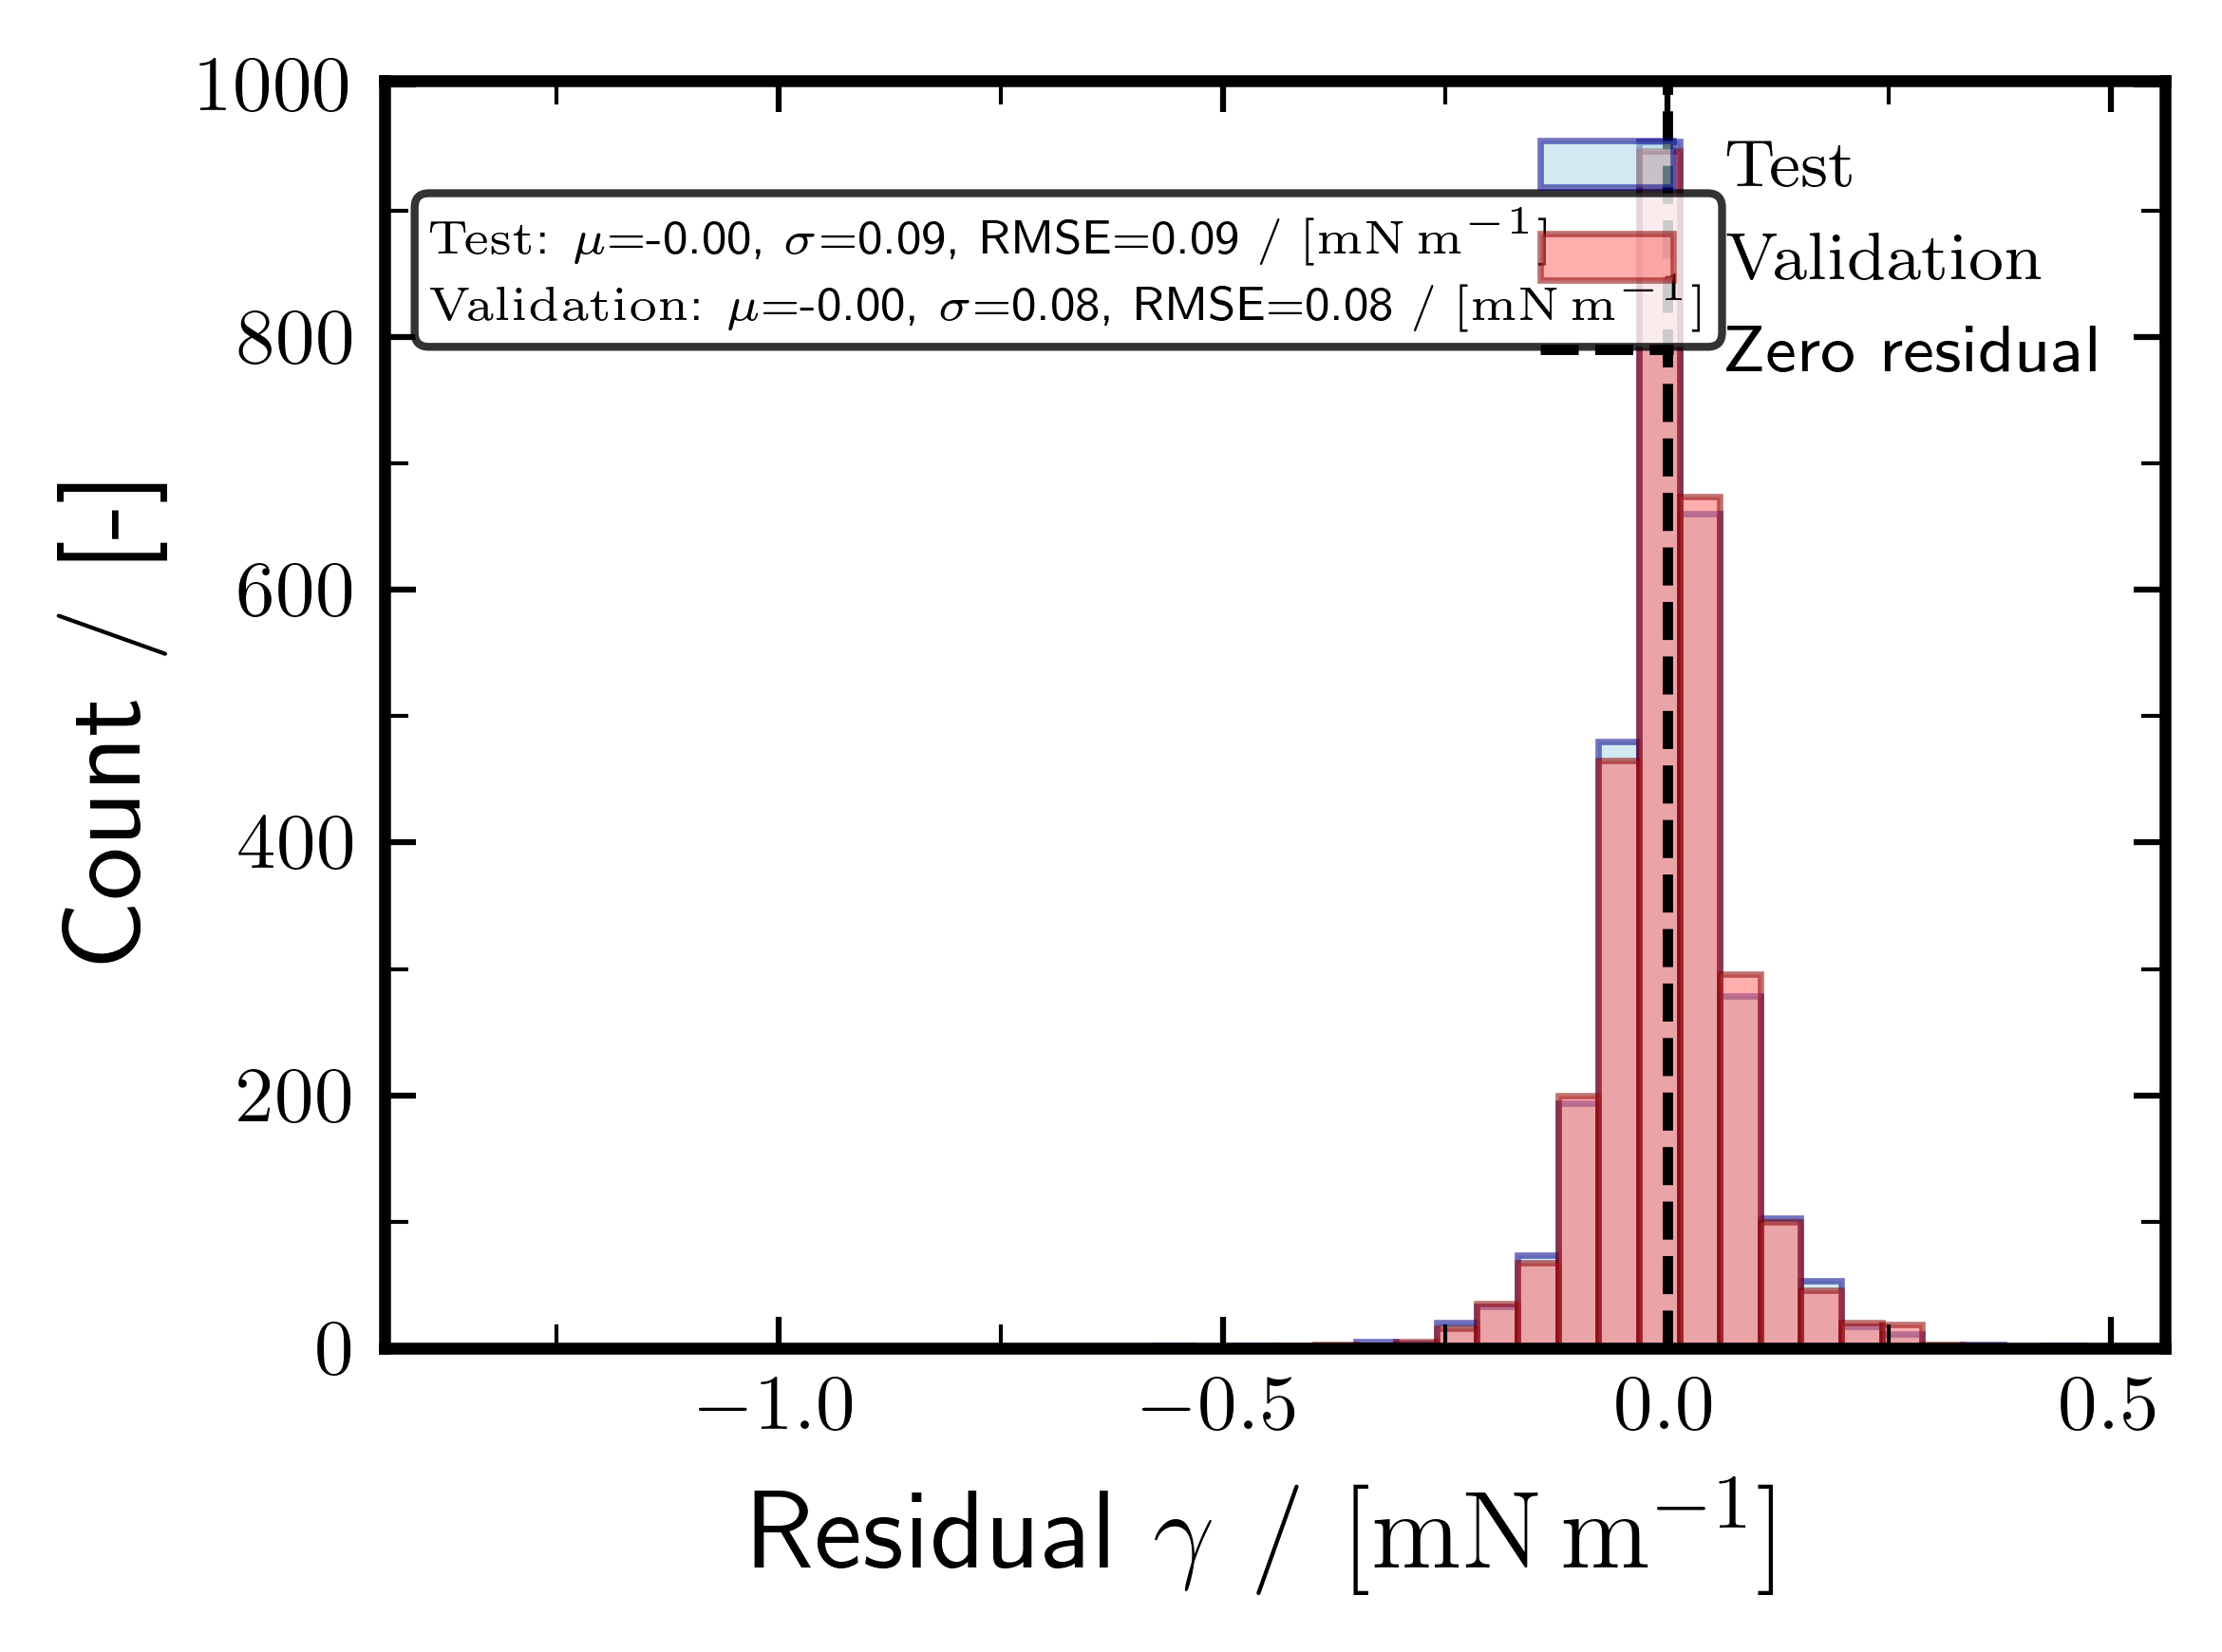

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='Count / [-]'>)

In [17]:
# Residual distribution
post.plot_residual_distribution(save_path="XGB_gamma_residual_distribution", folder=OUTPUT_FOLDER)

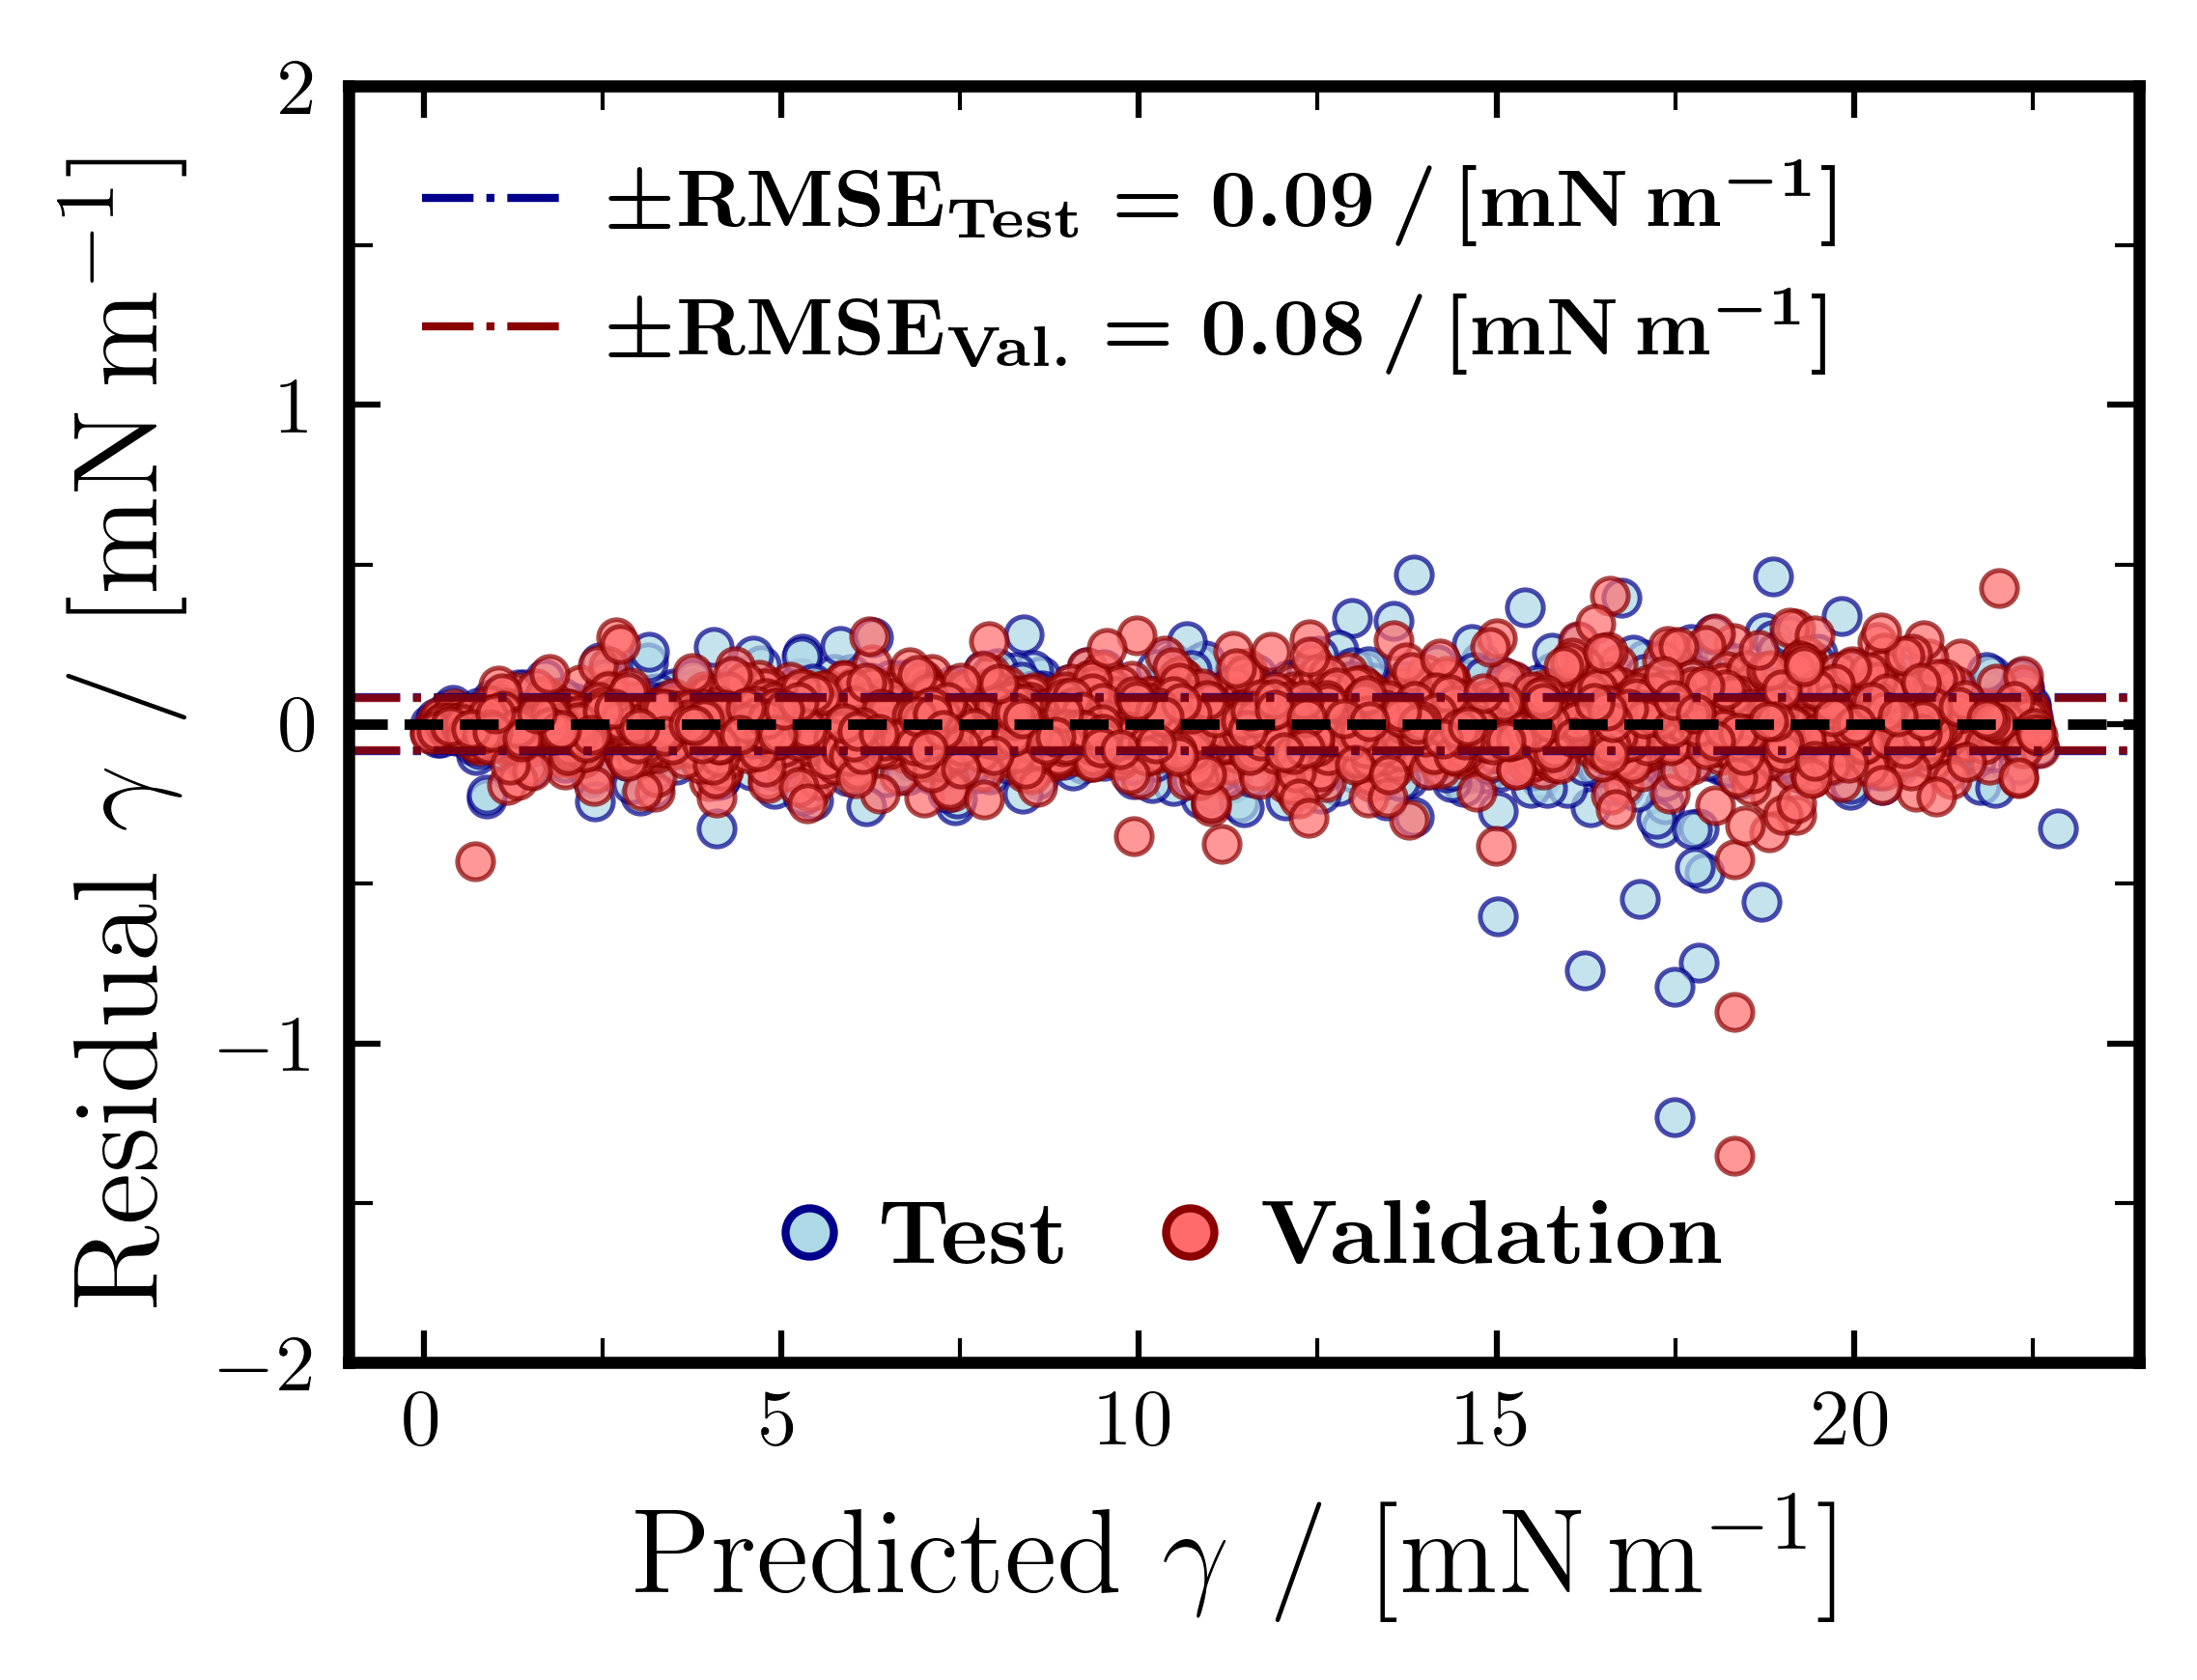

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Predicted}$ $\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='$\\mathrm{Residual}$ $\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>)

In [18]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="XGB_gamma_residual_vs_predicted",
                                y_range=[-2,2],folder=OUTPUT_FOLDER,
                                legend_loc="lower center", # Test/Validation marker-legend location
legend_handletextpad=0.3, # gap between marker and text
legend_handlelength=1.0, # marker-box width (smaller -> marker closer to text)
label_fontsize=15, # x/y axis label size
labelpad=4, # gap between axis and its label (points)
decimals=2, # decimal places for RMSE in legend)
)

In [19]:
post.print_summary()

# Collect and save all metrics
metrics["cv_r2_scores"]    = cv_r2_scores.tolist()
metrics["cv_r2_mean"]      = float(cv_r2_scores.mean())
metrics["cv_r2_std"]       = float(cv_r2_scores.std())
metrics["cv_rmse_scores"]  = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]    = float(cv_rmse_scores.mean())
metrics["cv_rmse_std"]     = float(cv_rmse_scores.std())
metrics["cv_mae_scores"]   = cv_mae_scores.tolist()
metrics["cv_mae_mean"]     = float(cv_mae_scores.mean())
metrics["cv_mae_std"]      = float(cv_mae_scores.std())
metrics["cv_mape_scores"]  = (cv_mape_scores * 100).tolist()
metrics["cv_mape_mean"]    = float(cv_mape_scores.mean() * 100)
metrics["cv_mape_std"]     = float(cv_mape_scores.std() * 100)
metrics["n_est_sweep_values"]     = n_est_values
metrics["n_est_sweep_test_rmse"]  = test_rmse_n
metrics["n_est_sweep_cv_rmse"]    = cv_rmse_n
metrics["depth_sweep_values"]     = depth_values
metrics["depth_sweep_test_rmse"]  = test_rmse_d
metrics["depth_sweep_cv_rmse"]    = cv_rmse_d
metrics["lr_sweep_values"]        = lr_values
metrics["lr_sweep_test_rmse"]     = test_rmse_lr
metrics["lr_sweep_cv_rmse"]       = cv_rmse_lr
metrics["model"]           = "XGBoost"
metrics["n_estimators"]    = xgb_model.n_estimators
metrics["max_depth"]       = xgb_model.max_depth
metrics["learning_rate"]   = xgb_model.learning_rate
metrics["subsample"]       = xgb_model.subsample
metrics["colsample_bytree"]= xgb_model.colsample_bytree
metrics["features"]        = features
metrics["target"]          = target
metrics["seed"]            = SEED

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
metrics_path = os.path.join(OUTPUT_FOLDER, f"XGB_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - GAMMA
Samples:        2904
R² Score:       0.999809
RMSE:           0.085155
MAE:            0.055000
Mean Residual:  -0.001589
Std Residual:   0.085140

FEATURE IMPORTANCES:
------------------------------------------------------------
  temperature               |  85.21% | ██████████████████████████████████████████
  pressure                  |  11.30% | █████
  z_hydrogen                |   2.17% | █
  z_carbon dioxide          |   0.56% | 
  z_nitrogen                |   0.25% | 
  z_methane                 |   0.17% | 
  z_hydrogen sulfide        |   0.16% | 
  z_argon                   |   0.10% | 
  z_carbon monoxide         |   0.06% | 
  z_oxygen                  |   0.02% | 

Metrics saved to: SLURM_gamma/XGB_gamma_metrics.json


In [20]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 1.76 minutes
